**Telecom X Parte 2**    

### 1. Predicción de Fuga de Clientes (Churn Prediction)

Este cuaderno representa la fase dos del 'Challenge Telecom X', centrándose en el desarrollo de modelos predictivos diseñados para la anticipación proactiva de la fuga de clientes (churn). La implementación se basará en los conjuntos de datos preprocesados y validados durante la Parte 1 de este proyecto.

### 1.1 Objetivo Estratégico

El propósito fundamental de este proyecto es la conceptualización, construcción y validación rigurosa de modelos predictivos. Estos modelos tienen como finalidad primordial la identificación temprana de segmentos de clientes en Telecom X que exhiben una probabilidad elevada de incurrir en churn, con el objetivo último de fundamentar decisiones estratégicas orientadas a la retención de clientes.

### 1.2 Impacto del Análisis

La ejecución de este análisis facilitará la estratificación y priorización de intervenciones de retención. Dicha priorización se fundamentará en la identificación de variables con una influencia estadísticamente significativa en la propensión a la cancelación del servicio.

### 1.3 Continuidad y Trazabilidad con la Fase Previa

Con el objetivo de preservar la coherencia analítica, esta segunda fase del desafío técnico se fundamenta exclusivamente en el conjunto de datos resultante de la Fase 1 del proyecto. Dicho _dataset_ ha sido previamente sometido a procesos exhaustivos de limpieza, estandarización y validación.

La carga de este conjunto de datos se realiza directamente desde su formato CSV, lo que evita la redundancia de las etapas de Extracción, Transformación y Carga (ETL) y garantiza la trazabilidad metodológica de las decisiones analíticas a lo largo de todo el ciclo de vida del proyecto.

El presente análisis sigue una proceso que cubre la comprensión del negocio, la comprensión de los datos, la preparación de datos y análisis exploratorio. La fase de modelado predictivo será abordada en secciones subsecuentes.

Es crucial destacar que en esta etapa no se procede a la construcción de modelos predictivos. El enfoque principal reside en asegurar la calidad, coherencia y viabilidad del _dataset_ para optimizar el rendimiento y la robustez de los modelos que se desarrollarán posteriormente.

### 2. Carga y Comprensión de los Datos

### 2.1 Carga del Conjunto de Datos Preprocesado

En esta sección se procede a la carga del conjunto de datos resultante de la Fase 1 del 'Challenge Telecom X'. Este _dataset_ ha sido previamente sometido a un proceso exhaustivo de preprocesamiento, lo que asegura la consolidación y estandarización de la información relevante acerca de los clientes de la entidad.

Este conjunto de datos constituye el fundamento para el desarrollo de los modelos predictivos, garantizando la coherencia analítica y eliminando la necesidad de duplicar las operaciones de limpieza y transformación de datos.

**Carga del conjunto de datos**

In [42]:
import pandas as pd # Importa la librería pandas para manipulación de datos

# URL del conjunto de datos preprocesado alojado en GitHub
url = "https://raw.githubusercontent.com/atapia9/DT/main/data/datos_tratados.csv"

try:
    # Intenta cargar el conjunto de datos desde la URL especificada
    df = pd.read_csv(url)
    print("Dataset cargado exitosamente.")

    # Verifica si la columna 'Churn' existe en el DataFrame
    if 'Churn' in df.columns:
        # Convierte la columna 'Churn' de valores categóricos ('Yes', 'No') a numéricos (1, 0)
        # 'Yes' se mapea a 1 (indicando fuga de clientes) y 'No' a 0 (indicando no fuga).
        # Luego, se convierte el tipo de dato de la columna a entero (int) para consistencia.
        df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
        print("Columna 'Churn' convertida a formato numérico.")
    else:
        # Si la columna 'Churn' no se encuentra, emite una advertencia
        print("Advertencia: La columna 'Churn' no se encontró en el dataset.")

    # Muestra las primeras 5 filas del DataFrame para una verificación inicial de la carga y transformación
    display(df.head())

except FileNotFoundError:
    # Captura el error si el archivo no se encuentra en la URL y eleva una excepción con un mensaje descriptivo
    raise RuntimeError(f"Error: El archivo no se encontró en la URL: {url}. Verifica la ruta.")
except Exception as e:
    # Captura cualquier otra excepción que pueda ocurrir durante la carga del dataset
    # y eleva una excepción con un mensaje que incluye el detalle del error original
    raise RuntimeError(f"No se pudo cargar el dataset desde {url}. Verifica la URL del repositorio o el formato del archivo. Detalle del error: {e}") from e


Dataset cargado exitosamente.
Columna 'Churn' convertida a formato numérico.


,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,0,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,0,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,1,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,1,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,1,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


### 2.2 Análisis de Valores Faltantes

Procedemos a verificar la presencia de valores nulos o faltantes en el conjunto de datos `df`. Este paso es crucial para asegurar la integridad de los datos y determinar si se requieren estrategias de imputación o limpieza adicionales antes del modelado predictivo.

**Verificando estructura**

In [43]:
# Calcula el número total de valores nulos por columna
missing_values_count = df.isnull().sum()

# Calcula el porcentaje de valores nulos por columna
missing_values_percentage = 100 * df.isnull().sum() / len(df)

# Crea un DataFrame para mostrar el conteo y el porcentaje de valores faltantes
missing_values_df = pd.DataFrame({
    'Conteo de Valores Faltantes': missing_values_count,
    '% de Valores Faltantes': missing_values_percentage
})

# Filtra las columnas que tienen al menos un valor faltante y las ordena de mayor a menor porcentaje
missing_values_df = missing_values_df[missing_values_df['Conteo de Valores Faltantes'] > 0].sort_values(by='% de Valores Faltantes', ascending=False)

# Imprime los resultados
if missing_values_df.empty:
    print("No se encontraron valores faltantes en el dataset.")
else:
    print("Análisis de Valores Faltantes:")
    display(missing_values_df)

No se encontraron valores faltantes en el dataset.


### 2.3 Definición de la Variable Dependiente

Dentro de este conjunto de datos, la variable dependiente de interés se define como la **tasa de rotación o 'churn' de clientes**, la cual cuantifica la discontinuidad del servicio por parte de los suscriptores de Telecom X.

La precisa caracterización de esta variable es fundamental, ya que constituye la base para la formulación de los problemas de clasificación predictiva, la selección de las métricas de evaluación pertinentes y la interpretación consecuente de los resultados derivados de los modelos predictivos desarrollados. Es importante recordar que la columna `Churn` ya ha sido codificada numéricamente (1 para abandono, 0 para permanencia) para su integración en los modelos.

**Verificando existencia de variable objetivo**

In [44]:
# Se verifica si la variable objetivo 'Churn' está presente en el DataFrame.
# Esta es una validación crítica para asegurar que el dataset contiene la información necesaria para el modelado.
if 'Churn' in df.columns:
    print("La variable objetivo 'Churn' se ha identificado correctamente en el dataset.")
    # Puedes mostrar información adicional si lo deseas, por ejemplo, los primeros valores
    # display(df['Churn'].head())
else:
    print("Error: La variable objetivo 'Churn' no se encuentra en el dataset. Por favor, verifica el preprocesamiento.")

La variable objetivo 'Churn' se ha identificado correctamente en el dataset.


**Exploración básica de variable objetivo**

In [45]:
# Muestra los valores únicos presentes en la columna 'Churn'.
# Para una variable objetivo binaria (como Churn), esto debería retornar [0, 1].
print("Valores únicos en la columna 'Churn':")
display(df["Churn"].unique())

# Calcula la frecuencia de cada valor único en la columna 'Churn'.
# Esto es crucial para entender la distribución de la variable objetivo y detectar posibles desbalances de clases.
print("Distribución de la variable objetivo 'Churn':")
display(df["Churn"].value_counts())

# Calcula el porcentaje de cada valor único.
print("Porcentaje de la variable objetivo 'Churn':")
display(df["Churn"].value_counts(normalize=True).mul(100).astype(str) + '%')

Valores únicos en la columna 'Churn':


array([0, 1])

Distribución de la variable objetivo 'Churn':


,count
Churn,
0,5174
1,1869


Porcentaje de la variable objetivo 'Churn':


,proportion
Churn,
0,73.4630129206304%
1,26.536987079369588%


**Tipo de dato de variable objetivo**

In [46]:
# Muestra el tipo de dato actual de la columna 'Churn'.
# Es fundamental que la variable objetivo sea de un tipo de dato numérico (entero o flotante)
# para que los algoritmos de Machine Learning puedan procesarla correctamente.
print(f"El tipo de dato de la variable objetivo 'Churn' es: {df['Churn'].dtype}")


El tipo de dato de la variable objetivo 'Churn' es: int64


**Contabilidad de observaciones por clase**

In [47]:
# Calcula el conteo absoluto de cada clase en la columna 'Churn'.
# Esto muestra cuántos clientes han cancelado el servicio (1) y cuántos no (0).
# Es útil para entender la magnitud de cada grupo y si existe un desbalance significativo.
display(df["Churn"].value_counts())

,count
Churn,
0,5174
1,1869


**Contabilidad proporcional**

In [48]:
# Calcula la proporción (porcentaje) de cada clase en la columna 'Churn'.
# El parámetro 'normalize=True' devuelve las frecuencias relativas en lugar de las absolutas.
# Esto es útil para entender el balance de clases en términos porcentuales.
display(df["Churn"].value_counts(normalize=True).mul(100).astype(str) + '%')

,proportion
Churn,
0,73.4630129206304%
1,26.536987079369588%


##3. Preparación de dataset para modelado

**3.1 Eliminación de columnas irrelevantes**

## 3. Preparación del Dataset para Modelado

### 3.1 Eliminación de Columnas Irrelevantes

En esta etapa, se procede a la exclusión de aquellas columnas que, tras un análisis previo, se han identificado como no aportantes de valor predictivo significativo para el modelo de Machine Learning. Esto incluye, pero no se limita a, identificadores únicos (como `CustomerID`) o cualquier otra variable que no contenga información relevante para la predicción de la fuga de clientes.

Este paso es fundamental para optimizar el rendimiento del modelo, ya que permite reducir el ruido en los datos, mitigar el riesgo de sobreajuste (_overfitting_) y asegurar que el entrenamiento se realice únicamente con variables que presenten una correlación o influencia demostrable sobre la variable objetivo.

**Revisión inicial de columnas**

In [49]:
# Muestra todas las columnas presentes en el DataFrame.
# Este paso es crucial para una revisión inicial e identificar columnas que podrían ser irrelevantes
# (como identificadores únicos) o que no aportan valor predictivo antes de proceder con su eliminación.
display(df.columns)

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

**Detección de características sin valor predictivo**

In [50]:
# Se identifica 'CustomerID' como una columna irrelevante para el modelado predictivo.
# Los identificadores únicos no aportan valor predictivo y pueden causar sobreajuste.
# Por lo tanto, se recomienda su eliminación antes de entrenar cualquier modelo.
columnas_a_eliminar = ['CustomerID']

# Muestra las columnas identificadas para eliminación
display(columnas_a_eliminar)

['CustomerID']

**Eliminación de columna irrelevante**

In [51]:
# Elimina la columna 'CustomerID' del DataFrame.
# 'CustomerID' es un identificador único que no aporta valor predictivo
# y puede introducir ruido o sobreajuste en el modelo.
# La eliminación se realiza 'in place' o asignando el resultado a 'df'.
df = df.drop(columns=columnas_a_eliminar)

print(f"Columna(s) {columnas_a_eliminar} eliminada(s) exitosamente.")
print("Columnas restantes en el DataFrame:")
display(df.columns)

Columna(s) ['CustomerID'] eliminada(s) exitosamente.
Columnas restantes en el DataFrame:


Index(['Churn', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'ChargesDaily', 'ChargesMonthly', 'ChargesTotal'],
      dtype='object')

**Dimensión de dataset después de eliminación**

In [52]:
# Muestra la dimensión actual del DataFrame (número de filas, número de columnas)
# después de haber eliminado las columnas irrelevantes como 'CustomerID'.
# Esto confirma que la operación de eliminación se realizó correctamente y reduce la dimensionalidad del dataset.
print(f"Dimensiones del DataFrame después de la eliminación de columnas irrelevantes: {df.shape}")

Dimensiones del DataFrame después de la eliminación de columnas irrelevantes: (7043, 21)


### 3.2 Imputación y Gestión de Valores Ausentes

En esta sección se aborda la identificación sistemática y el tratamiento subsiguiente de los valores ausentes (NaN) que pudieran persistir en el conjunto de datos. La finalidad primordial es garantizar la robustez y la completitud del _dataset_, previniendo la introducción de sesgos o la degradación del rendimiento durante las fases posteriores de entrenamiento y validación de modelos predictivos.

Las estrategias de imputación o remoción implementadas en este paso están diseñadas para optimizar la integridad informativa, minimizando la pérdida de datos y maximizando la representatividad del conjunto de entrenamiento.

### Identificación de Valores Faltantes

In [53]:
# Calcula la cantidad de valores faltantes por columna.
# Un resultado de 0 para todas las columnas indica que no hay valores nulos en el DataFrame.
print("Valores faltantes por columna:")
display(df.isna().sum())

Valores faltantes por columna:


,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Filas con Valores Faltantes

In [54]:
# Muestra todas las filas que contienen al menos un valor faltante.
# Si no hay valores faltantes, este resultado será un DataFrame vacío, confirmando su ausencia.
print("Filas que contienen valores faltantes:")
display(df[df.isna().any(axis=1)])

Filas que contienen valores faltantes:


,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal


### Conteo de Filas con Valores Faltantes

In [55]:
# Calcula el número total de filas que tienen al menos un valor faltante.
# Si el resultado es 0, significa que el dataset está completo y no hay filas con datos ausentes.
num_filas_con_nulos = df.isna().any(axis=1).sum()
print(f"Número total de filas con al menos un valor faltante: {num_filas_con_nulos}")

Número total de filas con al menos un valor faltante: 0


### Eliminación o Mantenimiento de Filas con Valores Faltantes

In [56]:
# Dado que el análisis previo ('df.isna().sum()' y 'missing_values_df' vacío) indicó que no hay valores faltantes,
# no es necesario ejecutar la operación df.dropna().
# Si hubiera valores faltantes, la línea de código sería 'df = df.dropna()'
# para eliminar las filas que contengan al menos un valor nulo.

if num_filas_con_nulos == 0:
    print("No se encontraron valores faltantes, por lo que no se eliminaron filas.")
else:
    print(f"Se eliminaron {num_filas_con_nulos} filas con valores faltantes.")
    df = df.dropna()


No se encontraron valores faltantes, por lo que no se eliminaron filas.


### Verificación Posterior al Tratamiento

In [57]:
# Volvemos a verificar la presencia de valores faltantes para confirmar que la operación (o la no-operación)
# fue exitosa y que el DataFrame ahora está libre de valores nulos, o sigue estando libre de ellos.
print("Verificación de valores faltantes después del tratamiento:")
display(df.isna().sum())

Verificación de valores faltantes después del tratamiento:


,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Dimensión Final del Dataset

In [58]:
# Muestra la dimensión final del DataFrame (filas, columnas).
# Esto nos permite ver si el número de filas ha cambiado después del tratamiento de valores faltantes.
print(f"Dimensión del dataset después del tratamiento de valores faltantes: {df.shape}")

Dimensión del dataset después del tratamiento de valores faltantes: (7043, 21)


### 3.3 Clasificación y Tipificación de Variables

En esta sección se procede a la clasificación de las variables presentes en el _dataset_ según su naturaleza intrínseca: **variables numéricas**, **variables categóricas** y **variables binarias**.

Esta tipificación es un paso fundamental en la fase de preparación de datos, ya que permite la selección adecuada de las transformaciones subsiguientes. Dichas transformaciones incluyen, pero no se limitan a, la codificación (`encoding`) de variables categóricas y la estandarización o normalización (`scaling`) de variables numéricas. Una clasificación precisa es indispensable para la aplicación de algoritmos de Machine Learning y la optimización del rendimiento predictivo.

### 3.3.1 Identificación de Variables por Tipo de Dato

In [59]:
# Identifica las columnas que contienen datos numéricos (enteros o flotantes).
# Se excluye la variable objetivo 'Churn' de esta primera clasificación general de numéricas para una segmentación más precisa.
variables_numericas_raw = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identifica las columnas que contienen datos de tipo objeto, que generalmente corresponden a categorías o texto.
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

# Muestra las variables numéricas y categóricas identificadas.
print("Variables Numéricas (incluyendo posibles binarias/objetivo):", variables_numericas_raw)
print("Variables Categóricas:", variables_categoricas)

Variables Numéricas (incluyendo posibles binarias/objetivo): ['Churn', 'Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal']
Variables Categóricas: ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 3.3.2 Identificación de Variables Binarias

In [60]:
# Identifica variables binarias dentro de las numéricas, es decir, aquellas que solo tienen dos valores únicos.
# Se excluye explícitamente la variable 'Churn' ya que es nuestra variable objetivo binaria.
variables_binarias = [
    col for col in variables_numericas_raw
    if df[col].nunique() == 2 and col != 'Churn'
]

# Muestra las variables binarias encontradas.
print("Variables Binarias (excluyendo la variable objetivo 'Churn'):", variables_binarias)

Variables Binarias (excluyendo la variable objetivo 'Churn'): []


### 3.3.3 Identificación de Variables Numéricas Continuas

In [61]:
# Define la variable objetivo para exclusión explícita.
variable_objetivo = 'Churn'

# Filtra las variables numéricas para obtener solo las continuas, excluyendo las binarias y la variable objetivo.
variables_numericas_continuas = [
    col for col in variables_numericas_raw
    if col not in variables_binarias and col != variable_objetivo
]

# Muestra las variables numéricas continuas.
print("Variables Numéricas Continuas:", variables_numericas_continuas)

Variables Numéricas Continuas: ['Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal']


### 3.3.4 Resumen de la Clasificación de Variables

In [62]:
# Imprime un resumen de todas las variables clasificadas para una revisión final.
print("--- Clasificación Final de Variables ---")
print(f"Variable Objetivo: {variable_objetivo}")
print(f"Variables Binarias: {variables_binarias}")
print(f"Variables Numéricas Continuas: {variables_numericas_continuas}")
print(f"Variables Categóricas: {variables_categoricas}")

--- Clasificación Final de Variables ---
Variable Objetivo: Churn
Variables Binarias: []
Variables Numéricas Continuas: ['Tenure', 'ChargesDaily', 'ChargesMonthly', 'ChargesTotal']
Variables Categóricas: ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### 4. Análisis de la Proporción de Fuga (Churn)

**Nota Terminológica:** A lo largo del presente análisis, el término 'churn' será empleado de forma consistente para referirse a la cancelación del servicio por parte del cliente.

En esta sección, se procede a la evaluación de la distribución de la variable objetivo 'churn', con el propósito de discernir la proporción de clientes que optan por la cancelación del servicio en contraste con aquellos que lo mantienen activo.

Este análisis es crucial para la identificación de posibles desequilibrios en las clases, los cuales podrían incidir significativamente en el rendimiento y la evaluación subsiguiente de los modelos predictivos.

**4.1 Distribución de clases**

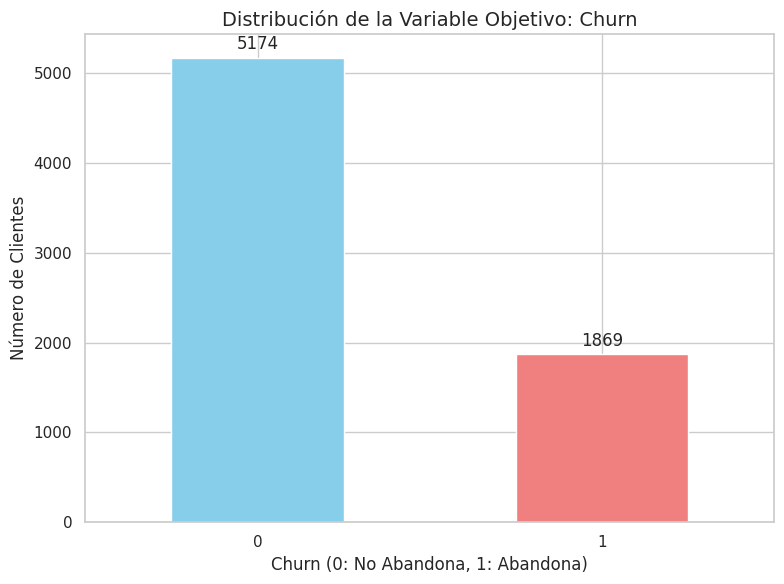

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para mejorar la visualización de los gráficos
sns.set_theme(style="whitegrid")

# Crea una figura y un conjunto de subtramas para el gráfico de barras
plt.figure(figsize=(8, 6))

# Genera el gráfico de barras de la distribución de la variable 'Churn'
# df['Churn'].value_counts() cuenta las ocurrencias de cada valor (0 y 1).
# .plot(kind='bar') crea un gráfico de barras.
ax = df["Churn"].value_counts().plot(kind="bar", color=['skyblue', 'lightcoral'])

# Añade un título al gráfico para describir su contenido
plt.title("Distribución de la Variable Objetivo: Churn", fontsize=14)

# Etiqueta el eje X para indicar lo que representa
plt.xlabel("Churn (0: No Abandona, 1: Abandona)", fontsize=12)

# Etiqueta el eje Y para indicar lo que representa
plt.ylabel("Número de Clientes", fontsize=12)

# Rota las etiquetas del eje X para que sean más legibles, especialmente si hay muchas categorías
plt.xticks(rotation=0) # Generalmente no se necesita rotación para 2 categorías

# Añade etiquetas de valor en la parte superior de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

# Ajusta el diseño para asegurar que todos los elementos se ajusten y no se superpongan
plt.tight_layout()

# Muestra el gráfico
plt.show()

**4.2 Desbalance de datos**

El análisis visual de la distribución de la variable `Churn` confirma el desequilibrio de clases previamente identificado: existe una proporción significativamente mayor de clientes que no han cancelado el servicio (clase '0') en comparación con aquellos que sí lo han hecho (clase '1').

Este desbalance es un factor crítico a considerar durante las fases de modelado, ya que podría llevar a modelos predictivos sesgados que favorezcan la clase mayoritaria. Se requerirán técnicas de manejo de desbalance de clases (como _oversampling_, _undersampling_ o el uso de algoritmos conscientes del desbalance) para asegurar un rendimiento equitativo y robusto del modelo en ambas clases.

In [64]:
# Calcula el conteo absoluto de cada clase en la columna 'Churn'.
churn_counts = df["Churn"].value_counts()

# Calcula el porcentaje de cada clase en la columna 'Churn'.
# Se multiplica por 100 y se redondea a 2 decimales para una mejor legibilidad.
churn_percent = df["Churn"].value_counts(normalize=True) * 100

# Crea un DataFrame resumen combinando el conteo y el porcentaje.
# Esto proporciona una vista concisa de la distribución de la variable objetivo.
churn_summary = pd.DataFrame({
    "Cantidad": churn_counts,
    "Porcentaje (%)": churn_percent.round(2)
})

# Muestra el DataFrame resumen
display(churn_summary)

,Cantidad,Porcentaje (%)
Churn,,
0,5174,73.46
1,1869,26.54


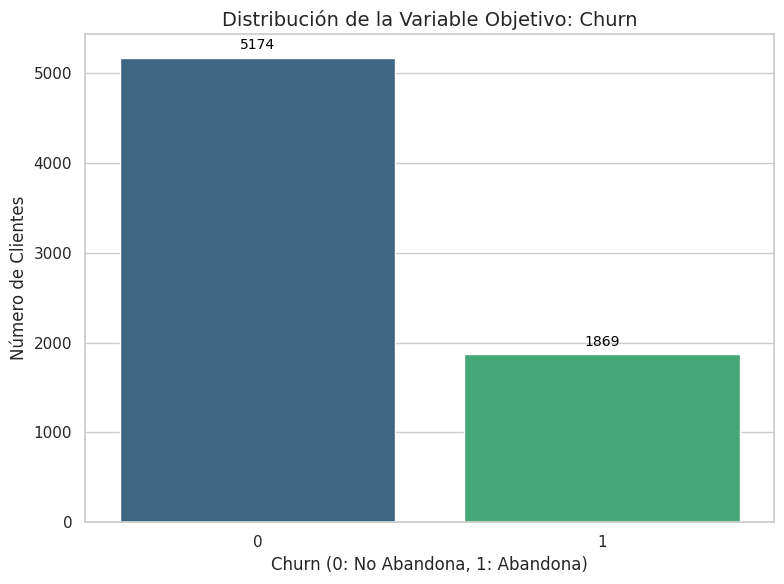

In [65]:
import matplotlib.pyplot as plt # Importa la librería Matplotlib para la creación de gráficos
import seaborn as sns         # Importa la librería Seaborn para gráficos estadísticos mejorados

# Configura el tema visual de Seaborn para gráficos más atractivos y profesionales
sns.set_theme(style="whitegrid")

# Crea una figura para el gráfico y define su tamaño
plt.figure(figsize=(8, 6))

# Calcula el conteo de cada clase en la variable 'Churn' (0: No Abandona, 1: Abandona)
churn_counts = df["Churn"].value_counts()

# Crea un gráfico de barras utilizando Seaborn y los conteos de churn
# 'x=churn_counts.index' define las categorías (0 y 1) en el eje X.
# 'y=churn_counts.values' define las alturas de las barras (cantidades) en el eje Y.
# Se ha actualizado la llamada a `sns.barplot` para asignar `x` también a `hue` y establecer `legend=False`,
# lo cual es la forma recomendada por la advertencia de `FutureWarning`.
ax = sns.barplot(x=churn_counts.index, y=churn_counts.values, hue=churn_counts.index, palette="viridis", legend=False)

# Añade un título descriptivo al gráfico
plt.title("Distribución de la Variable Objetivo: Churn", fontsize=14)

# Etiqueta el eje X para claridad
plt.xlabel("Churn (0: No Abandona, 1: Abandona)", fontsize=12)

# Etiqueta el eje Y para claridad
plt.ylabel("Número de Clientes", fontsize=12)

# Añade las etiquetas de valor (número exacto de clientes) encima de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, color='black')

# Ajusta automáticamente los parámetros de la trama para que se ajuste a la figura
plt.tight_layout()

# Muestra el gráfico
plt.show()

**Análisis de desbalance**

El análisis de la distribución de la variable objetivo revela un **desbalance moderado** en las clases, donde la mayoría de las observaciones corresponden a la clase 'no-churn' (permanencia del cliente), mientras que la clase 'churn' (fuga de clientes) representa una proporción minoritaria del dataset. Esta distribución refleja un escenario realista del comportamiento de los clientes en un contexto de negocio.

Este desbalance, aunque moderado, es un factor crítico a considerar durante las fases de modelado y evaluación, ya que métricas tradicionales como la _accuracy_ pueden resultar engañosas al favorecer a la clase mayoritaria y enmascarar el desempeño real en la detección de la clase minoritaria (churn). Por consiguiente, se priorizará el uso de métricas más robustas y sensibles a desbalances, tales como **precision, recall, F1-score y el área bajo la curva ROC (ROC-AUC)**, además de un análisis detallado de la matriz de confusión.

En esta etapa inicial, se ha decidido **no aplicar técnicas de balanceo de datos (e.g., _oversampling_, _undersampling_)**. El objetivo es establecer un rendimiento base (_baseline_) de los modelos predictivos utilizando la distribución natural de los datos, para posteriormente evaluar la necesidad y el impacto de estrategias de balanceo en la optimización del modelo.

**Observación de desbalance de variable objetivo**

El análisis de la distribución de la variable objetivo revela un **desbalance moderado** en las clases, donde la mayoría de las observaciones corresponden a la clase 'no-churn' (permanencia del cliente), mientras que la clase 'churn' (fuga de clientes) representa una proporción minoritaria del dataset. Esta distribución refleja un escenario realista del comportamiento de los clientes en un contexto de negocio.

Este desbalance, aunque moderado, es un factor crítico a considerar durante las fases de modelado y evaluación, ya que métricas tradicionales como la _accuracy_ pueden resultar engañosas al favorecer a la clase mayoritaria y enmascarar el desempeño real en la detección de la clase minoritaria (churn). Por consiguiente, se priorizará el uso de métricas más robustas y sensibles a desbalances, tales como **precision, recall, F1-score y el área bajo la curva ROC (ROC-AUC)**, además de un análisis detallado de la matriz de confusión.

En esta etapa inicial, se ha decidido **no aplicar técnicas de balanceo de datos (e.g., _oversampling_, _undersampling_)**. El objetivo es establecer un rendimiento base (_baseline_) de los modelos predictivos utilizando la distribución natural de los datos, para posteriormente evaluar la necesidad y el impacto de estrategias de balanceo en la optimización del modelo.

### 5. Análisis de las Relaciones Predictivas entre Variables

En esta sección, se procede a la evaluación de las relaciones estadísticas intrínsecas entre las variables numéricas del _dataset_, con el objetivo fundamental de:

*   **Identificar correlaciones lineales significativas** con la variable dependiente (Churn).
*   **Detectar la presencia de redundancia o multicolinealidad** entre las variables predictoras (explicativas).
*   **Priorizar las características clave** que aporten mayor valor predictivo para las subsiguientes fases de modelado y selección de atributos.

Este análisis se fundamentará en la aplicación de coeficientes de correlación de Pearson y en una revisión sistemática de la influencia de las variables más destacadas.

### 5.1 Matriz de Correlación

La matriz de correlación constituye una representación sistemática de la intensidad y dirección de la relación lineal entre pares de variables numéricas. Coeficientes cercanos a `+1` o `-1` indican una correlación lineal fuerte y directa o inversa, respectivamente. Por el contrario, valores próximos a `0` sugieren la ausencia o una correlación lineal insignificante entre las variables examinadas. Este análisis es fundamental para identificar posibles relaciones predictivas y para detectar fenómenos de multicolinealidad entre las características del _dataset_.

**Exploración de la matriz de correlación**

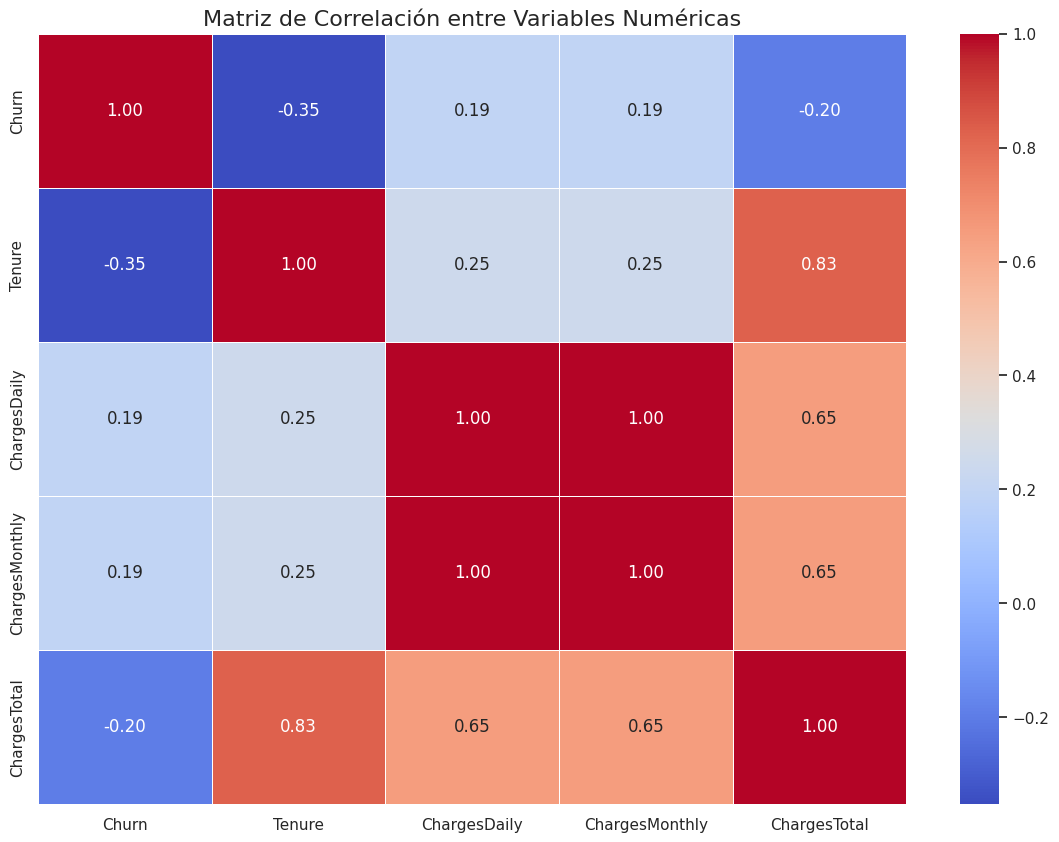

In [66]:
import pandas as pd         # Importa la librería pandas para manipulación de datos
import matplotlib.pyplot as plt # Importa la librería matplotlib para la creación de gráficos
import seaborn as sns         # Importa la librería seaborn para gráficos estadísticos mejorados

# Seleccionar únicamente las variables numéricas del DataFrame para el cálculo de la correlación.
# Esto incluirá 'Churn' ya que es de tipo int64, permitiendo analizar su correlación con otras variables.
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calcular la matriz de correlación de Pearson entre todas las variables numéricas.
# La matriz de correlación muestra la relación lineal entre pares de variables.
correlation_matrix = numeric_df.corr()

# Configurar el tamaño de la figura para una mejor visualización de la matriz de calor.
plt.figure(figsize=(14, 10))

# Visualizar la matriz de correlación utilizando un mapa de calor (heatmap).
# 'cmap='coolwarm'' define la paleta de colores (rojo para correlación negativa, azul para positiva).
# 'annot=True' muestra los valores de correlación en las celdas para una lectura precisa.
# 'fmt=".2f"' formatea los valores de correlación a dos decimales.
# 'linewidths=0.5' añade líneas entre las celdas para una mejor separación.
sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f", # Formatea los valores a dos decimales
    linewidths=0.5
)

# Añadir un título descriptivo al gráfico de la matriz de correlación.
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=16)

# Mostrar el gráfico.
plt.show()

### 5.2 Interpretación de la Matriz de Correlación

La inspección de la matriz de correlación revela patrones de asociación lineal entre las variables numéricas y su relación con la variable objetivo, `Churn`.

*   **Relación con la Variable Objetivo (`Churn`)**: Se identifican variables con una magnitud de correlación significativa respecto a `Churn`. Aquellas con coeficientes de correlación más elevados (positivos o negativos) sugieren una mayor capacidad explicativa sobre la propensión a la fuga del cliente, indicando su potencial relevancia predictiva.

*   **Multicolinealidad entre Predictoras**: La matriz también permite detectar la presencia de alta correlación entre variables predictoras. La multicolinealidad, cuando es severa, puede afectar la estabilidad y la interpretabilidad de los modelos predictivos, lo cual deberá ser gestionado en etapas subsiguientes.

*   **Consideraciones Metodológicas**: Es importante destacar que el coeficiente de correlación de Pearson se aplica exclusivamente a variables numéricas, asumiendo una relación lineal. Este análisis preliminar no implica la eliminación de variables en esta fase, sino que proporciona una base empírica para guiar decisiones de ingeniería de características y selección de modelos, priorizando aquellas que demuestren mayor influencia sobre `Churn` y gestionando la redundancia.

### 5.3 Identificación de Variables con Mayor Relación con Churn

Posterior al cálculo y visualización de la matriz de correlación, la subsiguiente etapa metodológica se centra en la identificación sistemática de las variables que exhiben la relación más robusta con la variable dependiente (Churn). Este análisis es fundamental para:

*   **Priorizar características con alta capacidad predictiva** desde una perspectiva inicial.
*   **Optimizar el proceso de selección de atributos**, minimizando la inclusión de variables con bajo poder explicativo y reduciendo el ruido inherente a los datos.
*   **Sustentar las decisiones de modelado** con fundamentos estadísticos sólidos y una justificación estratégica alineada a los objetivos de negocio.

**Derección de variables más correlacionadas con Churn**

In [67]:
# Extrae la columna de correlación de 'Churn' de la matriz de correlación.
# Esta serie contendrá la correlación de cada variable numérica con 'Churn'.
churn_corr = correlation_matrix['Churn']

# Elimina la auto-correlación de 'Churn' consigo misma, ya que siempre es 1 y no aporta información.
churn_corr_filtered = churn_corr.drop('Churn')

# Ordena las correlaciones por su valor absoluto en orden descendente.
# Esto permite identificar las variables con la relación más fuerte, ya sea positiva o negativa.
top_corr = churn_corr_filtered.reindex(
    churn_corr_filtered.abs().sort_values(ascending=False).index
)

# Muestra las variables numéricas más correlacionadas con 'Churn' y sus respectivos coeficientes.
# Esto proporciona una visión rápida de las características más influyentes.
display(top_corr)

,Churn
Tenure,-0.352229
ChargesTotal,-0.198324
ChargesDaily,0.193412
ChargesMonthly,0.193356


El proceso de identificación de las variables más correlacionadas con `Churn` se inicia con la extracción de los coeficientes de correlación de Pearson para cada variable predictora respecto a la variable objetivo. Posteriormente, se excluye la autocorrelación de `Churn` consigo misma, y las correlaciones restantes se ordenan en función de su valor absoluto en orden descendente. Esta metodología permite:

*   **Priorizar la magnitud de la asociación**, independientemente de su dirección (positiva o negativa).
*   **Establecer un ranking empírico** de variables candidatas con potencial explicativo para análisis subsiguientes y modelado predictivo.

Las variables que exhiben los mayores valores de correlación absoluta con `Churn` son consideradas factores potencialmente influyentes en la decisión de cancelación del servicio por parte del cliente. En este contexto:

*   Las **correlaciones positivas** indican que un incremento en el valor de la variable predictora se asocia con una mayor probabilidad de ocurrencia de `Churn`.
*   Las **correlaciones negativas** sugieren que un incremento en el valor de la variable predictora está asociado con una menor probabilidad de `Churn`, implicando un posible efecto protector o de retención.

**Análisis visual de la correlación entre atributos y la variable objetivo**

**Análisis visual de la correlación entre atributos y la variable objetivo**

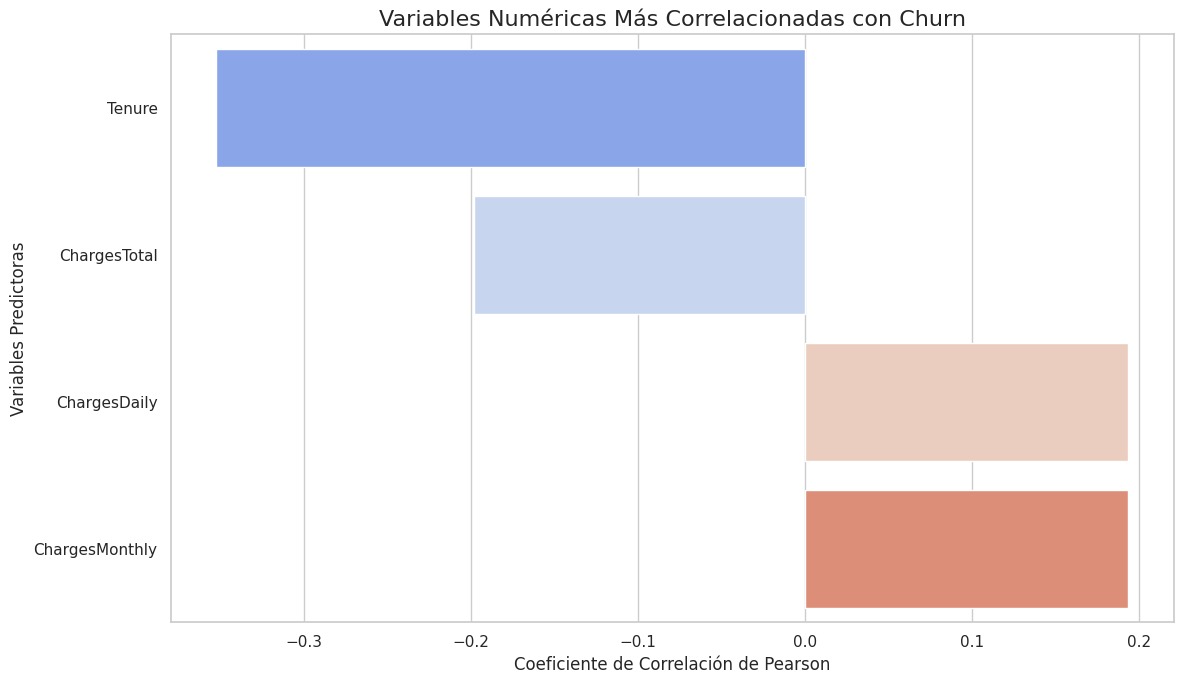

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aseguramos que 'top_corr' esté definido y sea un Series de pandas
# Si top_corr no estuviera definido, se debería recalcular (omito por brevedad, asumiendo está en scope)

# Creamos una figura con un tamaño adecuado para la visualización
plt.figure(figsize=(12, 7))

# Generamos un gráfico de barras horizontales usando seaborn para las variables más correlacionadas.
# Esto facilita la comparación de la magnitud de las correlaciones.
sns.barplot(x=top_corr.values, y=top_corr.index, hue=top_corr.index, palette='coolwarm', legend=False)

# Añadimos un título descriptivo al gráfico.
plt.title('Variables Numéricas Más Correlacionadas con Churn', fontsize=16)

# Etiquetamos el eje X para indicar lo que representa.
plt.xlabel('Coeficiente de Correlación de Pearson', fontsize=12)

# Etiquetamos el eje Y para indicar las variables.
plt.ylabel('Variables Predictoras', fontsize=12)

# Ajustamos el diseño para que todo el gráfico se vea correctamente.
plt.tight_layout()

# Mostramos el gráfico.
plt.show()

La visualización gráfica de las correlaciones facilita la **comparación directa de la magnitud y dirección de la relación lineal** entre las variables predictoras y la variable objetivo `Churn`. Este análisis provee una base empírica para:

*   **Fundamentar decisiones iniciales sobre la selección de características**, identificando aquellas variables con mayor potencial predictivo.
*   **Priorizar variables** que podrían requerir transformaciones específicas o ingeniería de características adicional.
*   **Comunicar hallazgos preliminares** sobre la influencia de las variables en la fuga de clientes, de manera accesible a perfiles no técnicos.

Es fundamental destacar que este análisis se circunscribe a la detección de **relaciones lineales** y su carácter es primordialmente **exploratorio y orientativo**. Para una evaluación exhaustiva de la importancia de las variables, será indispensable complementarlo con:

*   Análisis bivariados y multivariados más complejos.
*   La implementación de modelos de aprendizaje supervisado.
*   La evaluación de métricas de importancia de variables inherentes a los modelos.

**Nota de Transición Analítica:** Estos resultados visuales refuerzan la hipótesis inicial de que ciertas variables operativas y contractuales ejercen una influencia relevante sobre la propensión al `Churn`. No obstante, la validación y cuantificación precisa de esta relación se realizará mediante la construcción y evaluación de modelos predictivos en fases subsiguientes, donde se determinará su peso real en la capacidad de anticipar la cancelación de clientes.

### 5.3 Análisis Focalizado de Atributos Clave

Posterior a la revisión exhaustiva de la matriz de correlación, se procede a un análisis focalizado con el propósito de:

*   Identificar aquellos atributos que exhiben una correlación de mayor magnitud con la variable dependiente (Churn).
*   Validar la pertinencia de dichas relaciones desde una perspectiva de negocio y el comportamiento inherente del cliente.
*   Establecer un conjunto preliminar de variables candidatas para la inclusión en modelos predictivos.

**Representación gráfica de la influencia de variables en Churn**

**Representación gráfica de la influencia de variables en Churn**

In [69]:
# Calcula la correlación de cada variable numérica con la variable objetivo 'Churn'.
# Se ordenan los valores de forma descendente para ver las correlaciones más fuertes (positivas) primero.
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)

# Excluye la correlación de 'Churn' consigo misma, que siempre es 1 y no aporta información.
churn_correlation = churn_correlation.drop('Churn')

# Muestra las correlaciones resultantes.
# Esto nos da una vista rápida de qué variables tienen una relación lineal positiva o negativa con 'Churn'.
display(churn_correlation)

,Churn
ChargesDaily,0.193412
ChargesMonthly,0.193356
ChargesTotal,-0.198324
Tenure,-0.352229


La extracción de la columna de correlaciones asociada a la variable objetivo `Churn`, seguida de un ordenamiento descendente por magnitud, facilita la identificación ágil y sistemática de:

*   **Variables con correlación positiva:** Indicando que un incremento en el valor de la característica predictora se asocia con una mayor probabilidad de ocurrencia de `Churn`.
*   **Variables con correlación negativa:** Sugiriendo que un aumento en el valor de la característica predictora se relaciona con una menor probabilidad de `Churn`, lo que podría interpretarse como un factor de retención.

Es fundamental precisar que este análisis de correlación, si bien ofrece **señales predictivas valiosas**, no implica una relación de causalidad directa. Su utilidad principal radica en:

*   **Orientar la selección de variables** para modelos predictivos.
*   **Fundamentar decisiones de ingeniería de características**.
*   **Servir como base para la interpretación** de los resultados de modelos más complejos en fases subsiguientes.

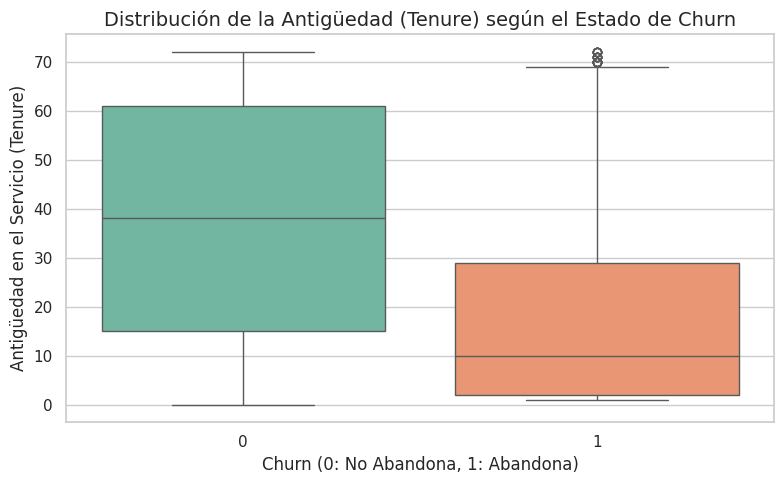

In [70]:
import seaborn as sns         # Importa la librería Seaborn para gráficos estadísticos mejorados
import matplotlib.pyplot as plt # Importa la librería Matplotlib para la creación de gráficos

# Configura el tamaño de la figura para una mejor visualización del boxplot.
plt.figure(figsize=(8, 5))

# Genera un boxplot para visualizar la distribución de 'Tenure' (antigüedad) en relación con 'Churn'.
# 'x='Churn'' define la variable categórica en el eje X (0: No Abandona, 1: Abandona).
# 'y='Tenure'' define la variable numérica continua en el eje Y (antigüedad en el servicio).
# 'data=df' especifica el DataFrame a utilizar.
# 'hue='Churn'' colorea los boxplots según la categoría de Churn, lo cual es útil para diferenciar visualmente y suprime advertencias.
# 'palette='Set2'' utiliza una paleta de colores predefinida de Seaborn.
# 'legend=False' oculta la leyenda ya que el eje X ya es descriptivo.
sns.boxplot(
    x='Churn',
    y='Tenure',
    data=df,
    hue='Churn',
    palette='Set2',
    legend=False
)

# Añade un título descriptivo al gráfico.
plt.title('Distribución de la Antigüedad (Tenure) según el Estado de Churn', fontsize=14)

# Etiqueta el eje X para indicar lo que representa.
plt.xlabel('Churn (0: No Abandona, 1: Abandona)', fontsize=12)

# Etiqueta el eje Y para indicar lo que representa.
plt.ylabel('Antigüedad en el Servicio (Tenure)', fontsize=12)

# Ajusta automáticamente los parámetros de la trama para que se ajuste a la figura.
plt.tight_layout()

# Muestra el gráfico.
plt.show()

En conjunto, el comportamiento observado en esta variable (`Tenure`) sugiere una asociación significativa con el riesgo de `Churn`. Las diferencias distintivas en la distribución de la antigüedad entre los clientes que retienen el servicio y aquellos que lo cancelan, la posicionan como una característica de alta relevancia para su inclusión y análisis en el modelado predictivo subsiguiente.

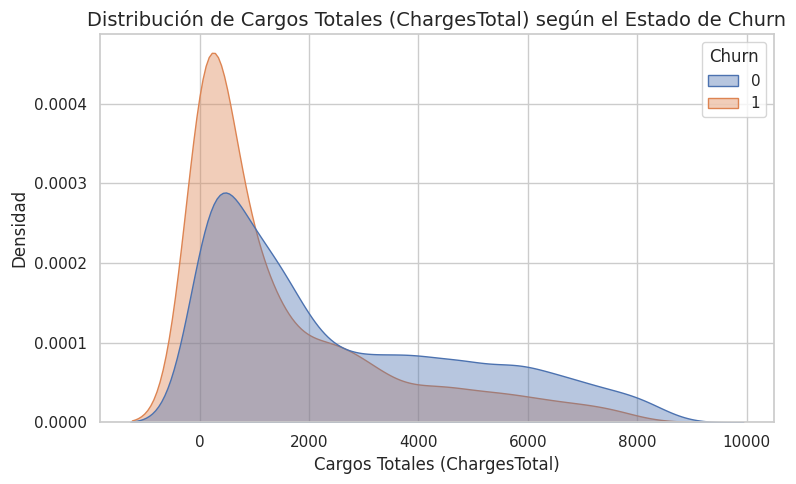

In [71]:
import seaborn as sns         # Importa la librería Seaborn para gráficos estadísticos mejorados
import matplotlib.pyplot as plt # Importa la librería Matplotlib para la creación de gráficos

# Configura el tamaño de la figura para una mejor visualización del KDE plot.
plt.figure(figsize=(8, 5))

# Genera un Kernel Density Estimate (KDE) plot para visualizar la distribución de 'ChargesTotal'.
# 'data=df' especifica el DataFrame a utilizar.
# 'x='ChargesTotal'' define la variable numérica continua en el eje X.
# 'hue='Churn'' divide la distribución según el estado de Churn (0: No Abandona, 1: Abandona).
# 'fill=True' rellena el área bajo las curvas de densidad para una mejor visualización.
# 'common_norm=False' normaliza cada curva de densidad de forma independiente, permitiendo comparar formas.
# 'alpha=0.4' ajusta la transparencia del relleno de las curvas.
sns.kdeplot(
    data=df,
    x='ChargesTotal',
    hue='Churn',
    fill=True,
    common_norm=False,
    alpha=0.4
)

# Añade un título descriptivo al gráfico.
plt.title('Distribución de Cargos Totales (ChargesTotal) según el Estado de Churn', fontsize=14)

# Etiqueta el eje X para indicar lo que representa.
plt.xlabel('Cargos Totales (ChargesTotal)', fontsize=12)

# Etiqueta el eje Y para indicar lo que representa (Densidad de probabilidad).
plt.ylabel('Densidad', fontsize=12)

# Ajusta automáticamente los parámetros de la trama para que se ajuste a la figura.
plt.tight_layout()

# Muestra el gráfico.
plt.show()

En casos donde una variable no exhibe diferencias significativas entre los grupos de `Churn` de forma individual o presenta una correlación lineal baja, su aporte predictivo aislado podría ser limitado. Es fundamental considerar que:

*   **Correlaciones lineales bajas** no implican una irrelevancia total; pueden existir relaciones no lineales o dependencias complejas que el coeficiente de Pearson no detecta.
*   **Variables categóricas**, una vez sometidas a procesos de codificación (e.g., *one-hot encoding*, codificación ordinal), podrían revelar nuevas relaciones predictivas.
*   La **evaluación definitiva de la importancia de las variables** debe complementarse con métricas derivadas de modelos de aprendizaje supervisado, que capturen interacciones y patrones multivariados.

### Conclusión Parcial del Análisis de Atributos Clave

El análisis dirigido y exploratorio confirma que las variables identificadas no solo presentan correlaciones estadísticas con `Churn`, sino que también exhiben una **coherencia con la lógica de negocio y el comportamiento del cliente**. Este alineamiento entre los hallazgos basados en datos y el contexto operacional justifica la inclusión prioritaria de estas variables en la fase de modelado predictivo.

Se reafirma que el fenómeno de `Churn` es de **naturaleza multicausal**, donde ninguna variable por sí sola explica completamente el comportamiento de cancelación. Esto subraya la necesidad de emplear modelos predictivos complejos que puedan capturar la interacción de múltiples factores (condiciones contractuales, uso del servicio, percepción de valor, etc.), en lugar de reglas estáticas. La jerarquización preliminar de variables basada en correlaciones servirá para **orientar la selección de atributos**, optimizando el rendimiento y la interpretabilidad de los modelos subsiguientes, y estableciendo una base sólida para avanzar hacia una etapa explicativa y prescriptiva de la fuga de clientes.

### 6. Preparación Final del Dataset para el Modelado Predictivo

En esta sección, se procede a la etapa final de preparación del _dataset_ con el objetivo primordial de optimizar su estructura y formato para la subsiguiente fase de modelado predictivo. Las operaciones clave incluyen la transformación de variables a formatos numéricos, la aplicación de escalas adecuadas a los atributos, y la segregación estratégica de los datos en conjuntos de entrenamiento y prueba, garantizando la integridad metodológica y previniendo el _data leakage_.

### 6.1 Transformación de Variables Categóricas (Encoding)

En este paso, las variables categóricas del _dataset_ se someten a un proceso de transformación hacia representaciones numéricas. Para aquellas variables nominales que carecen de un orden intrínseco inherente, se empleará la técnica de _One-Hot Encoding_, con el fin de evitar la introducción de relaciones ordinales artificiales entre las categorías y preservar la validez de las inferencias.

In [72]:
from sklearn.preprocessing import OneHotEncoder # Importa la clase OneHotEncoder para la transformación de variables categóricas
import pandas as pd # Asegura que pandas esté importado para operaciones con DataFrames

# Identificar las variables categóricas en el DataFrame.
# Se seleccionan columnas con tipo de dato 'object' (generalmente strings) o 'category'.
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Inicializar el OneHotEncoder.
# 'drop='first'' evita la multicolinealidad eliminando la primera categoría de cada característica.
# 'sparse_output=False' asegura que la salida sea una matriz densa (array numpy) en lugar de dispersa.
# 'handle_unknown='ignore'' permite al encoder ignorar categorías desconocidas durante la transformación,
# lo cual es útil si los datos de prueba contienen categorías no vistas en el entrenamiento.
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Aplicar One-Hot Encoding a las variables categóricas seleccionadas.
# 'fit_transform' aprende el vocabulario de las categorías y transforma los datos simultáneamente.
encoded_array = ohe.fit_transform(df[categorical_features])

# Convertir el array codificado en un DataFrame de pandas.
# 'ohe.get_feature_names_out(categorical_features)' genera los nombres de las nuevas columnas codificadas.
# 'index=df.index' asegura que el DataFrame codificado tenga el mismo índice que el original para una concatenación sencilla.
encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(categorical_features),
    index=df.index
)

# Eliminar las variables categóricas originales del DataFrame principal.
# Esto se hace para evitar la duplicidad de información una vez que se añaden las columnas codificadas.
df_dropped_categorical = df.drop(columns=categorical_features)

# Concatenar el DataFrame original (sin las columnas categóricas) con el DataFrame codificado.
# 'axis=1' indica que la concatenación se realiza por columnas.
df_encoded = pd.concat(
    [df_dropped_categorical, encoded_df],
    axis=1
)

# Mostrar las primeras filas del DataFrame resultante para verificar la transformación.
display(df_encoded.head())

,Churn,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,2.19,65.6,593.30,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0,9,2.00,59.9,542.40,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1,4,2.46,73.9,280.85,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1,13,3.27,98.0,1237.85,1.0,1.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1,3,2.80,83.9,267.40,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### 6.2 Normalización o Estandarización de Variables Numéricas

La aplicación de la estandarización o normalización a las variables numéricas es un proceso crítico en la preparación de datos. Este procedimiento transforma los datos para que presenten una escala común (típicamente con media `0` y desviación estándar `1`), mitigando el impacto de diferencias de magnitud entre las características.

Esta uniformidad de escala es particularmente relevante para algoritmos de Machine Learning sensibles a la magnitud de los datos, tales como la Regresión Logística, las Máquinas de Vectores de Soporte (SVM) y los k-vecinos más cercanos (KNN). La estandarización contribuye a una convergencia más eficiente de los algoritmos y a la prevención de que variables con rangos de valores amplios dominen indebidamente el proceso de aprendizaje del modelo.

In [73]:
from sklearn.preprocessing import StandardScaler # Importa la clase StandardScaler para estandarizar las variables

# Identificar las variables numéricas que necesitan ser estandarizadas.
# Se excluye explícitamente la variable 'Churn' ya que es la variable objetivo y no debe ser escalada.
numeric_features_to_scale = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Churn' in numeric_features_to_scale:
    numeric_features_to_scale.remove('Churn')

# Inicializar el StandardScaler.
# Este escalador transformará los datos para que tengan una media de 0 y una desviación estándar de 1.
scaler = StandardScaler()

# Aplicar la estandarización a las variables numéricas seleccionadas.
# 'fit_transform' calcula la media y la desviación estándar de los datos y luego los escala.
df_encoded[numeric_features_to_scale] = scaler.fit_transform(df_encoded[numeric_features_to_scale])

# Mostrar las estadísticas descriptivas del DataFrame transformado.
# Esto permite verificar que las variables numéricas ahora tienen una media cercana a 0 y una desviación estándar cercana a 1.
display(df_encoded.describe().T)

,count,mean,std,min,25%,50%,75%,max
Churn,7043.0,2.653699e-01,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Tenure,7043.0,-2.824818e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
ChargesDaily,7043.0,-1.150105e-16,1.000071,-1.544018,-0.975732,0.180779,0.828825,1.795907
ChargesMonthly,7043.0,-6.658501e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
ChargesTotal,7043.0,-4.237228e-17,1.000071,-1.005780,-0.829946,-0.390528,0.664803,2.825806
Gender_Male,7043.0,-2.320387e-17,1.000071,-1.009559,-1.009559,0.990532,0.990532,0.990532
SeniorCitizen_Yes,7043.0,-4.741660e-17,1.000071,-0.439916,-0.439916,-0.439916,-0.439916,2.273159
Partner_Yes,7043.0,1.230814e-16,1.000071,-0.966622,-0.966622,-0.966622,1.034530,1.034530
Dependents_Yes,7043.0,1.079484e-16,1.000071,-0.654012,-0.654012,-0.654012,1.529024,1.529024
PhoneService_Yes,7043.0,7.263819e-17,1.000071,-3.054010,0.327438,0.327438,0.327438,0.327438


### 6.3 Partición Estratégica del Dataset (Train-Test Split)

La separación del conjunto de datos en subconjuntos de entrenamiento y prueba es una práctica fundamental en el proceso de desarrollo y validación de modelos predictivos. Este procedimiento tiene como objetivo primordial evaluar la capacidad de generalización del modelo sobre datos no observados durante la fase de entrenamiento, mitigando así el riesgo de sobreajuste (_overfitting_).

Para preservar la representatividad de la variable objetivo y dada la naturaleza desbalanceada del `Churn`, la partición se realizará mediante una **estrategia de estratificación**. Esto asegura que la proporción de clases de `Churn` sea consistente tanto en el conjunto de entrenamiento como en el de prueba, lo cual es crucial para la robustez y equidad de las métricas de evaluación.

Esta segregación controlada del _dataset_ es imperativa para garantizar la validez metodológica de la evaluación del modelo y para la selección de hiperparámetros.

In [74]:
from sklearn.model_selection import train_test_split # Importa la función para dividir el dataset

# Definir las variables independientes (features) y la variable objetivo (target).
# 'X' contendrá todas las columnas excepto 'Churn', que es nuestra variable dependiente.
# 'y' contendrá únicamente la columna 'Churn'.
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Realizar la división del dataset en conjuntos de entrenamiento y prueba (Train-Test Split).
# 'test_size=0.2' asigna el 20% de los datos al conjunto de prueba y el 80% al de entrenamiento.
# 'random_state=42' asegura la reproducibilidad de la división.
# 'stratify=y' es crucial para mantener la misma proporción de la variable objetivo 'Churn'
# en ambos conjuntos, lo que es vital en casos de desbalance de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Muestra las dimensiones de los conjuntos resultantes para verificar la correcta división.
# Esto confirma el número de filas y columnas en cada subconjunto.
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (5634, 24)
Dimensiones de X_test: (1409, 24)
Dimensiones de y_train: (5634,)
Dimensiones de y_test: (1409,)


### Conclusión de la Preparación del Dataset para Modelado

Al culminar esta etapa crítica, el conjunto de datos (`dataset`) se ha transformado en una estructura optimizada para el modelado predictivo, caracterizada por:

1.  **Integridad de Datos**: El dataset se encuentra libre de valores faltantes y de columnas irrelevantes.
2.  **Representación Numérica**: Todas las variables categóricas han sido codificadas a un formato numérico adecuado (mediante One-Hot Encoding).
3.  **Homogeneidad de Escala**: Las variables numéricas han sido estandarizadas, presentando una media cercana a cero y una desviación estándar unitaria.
4.  **Partición Estratégica**: El dataset ha sido dividido en subconjuntos de entrenamiento y prueba mediante una estrategia de estratificación, preservando la distribución de la variable objetivo y garantizando la robustez de las evaluaciones futuras.

Este proceso ha sido ejecutado con especial énfasis en la prevención de la **fuga de datos (_data leakage_)**, asegurando que todas las transformaciones basadas en el conocimiento del conjunto de datos completo se aplicaran exclusivamente después de la segregación `train-test`. El dataset resultante está, por lo tanto, metodológicamente preparado para el entrenamiento y validación rigurosa de modelos predictivos.

### 7. Modelado Predictivo

Con base en los hallazgos del análisis exploratorio, se procede a la fase de modelado predictivo con el objetivo primordial de **estimar la probabilidad de fuga de clientes (Churn)** y evaluar la capacidad de distintos algoritmos para identificar patrones relevantes en los datos.

Dado el desbalance inherente en la variable objetivo, métricas como la _exactitud (accuracy)_ no resultan suficientes para una evaluación adecuada del desempeño de los modelos. Por consiguiente, se priorizará el uso de **métricas complementarias y robustas** (e.g., precisión, recall, F1-score, área bajo la curva ROC-AUC) que midan con mayor fiabilidad la capacidad del modelo para identificar clientes en riesgo de cancelación.

La estrategia de modelado contempla el entrenamiento de **modelos de clasificación complementarios**: se explorará tanto un enfoque lineal interpretable como un modelo basado en árboles con mayor capacidad para capturar relaciones no lineales. Esta selección busca un equilibrio entre el desempeño predictivo y la interpretabilidad, lo cual es fundamental en un contexto empresarial para no solo predecir con precisión, sino también para comprender los factores que influyen en la decisión de cancelación y habilitar acciones correctivas.

### 7.1 Preparación de Datos para el Modelado

Previo al entrenamiento de los modelos, se confirmará que los datos estén adecuadamente estructurados:

*   **Separación de Variables**: Se diferenciarán explícitamente las variables predictoras (X) de la variable objetivo (y).
*   **División en Conjuntos**: El dataset se dividirá en subconjuntos de entrenamiento y prueba, asegurando la capacidad de generalización del modelo sobre datos no vistos y la reproducibilidad mediante el establecimiento de un `random_state`.

In [75]:
from sklearn.model_selection import train_test_split # Importa la función para dividir el dataset

# Definir las variables independientes (features) y la variable objetivo (target).
# 'X' contendrá todas las columnas excepto 'Churn', que es nuestra variable dependiente.
# 'y' contendrá únicamente la columna 'Churn'.
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Realizar la división del dataset en conjuntos de entrenamiento y prueba (Train-Test Split).
# 'test_size=0.2' asigna el 20% de los datos al conjunto de prueba y el 80% al de entrenamiento.
# 'random_state=42' asegura la reproducibilidad de la división.
# 'stratify=y' es crucial para mantener la misma proporción de la variable objetivo 'Churn'
# en ambos conjuntos, lo que es vital en casos de desbalance de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Muestra las dimensiones de los conjuntos resultantes para verificar la correcta división.
# Esto confirma el número de filas y columnas en cada subconjunto.
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (5634, 24)
Dimensiones de X_test: (1409, 24)
Dimensiones de y_train: (5634,)
Dimensiones de y_test: (1409,)


### 7.2 Modelo Base (Baseline): Regresión Logística

La Regresión Logística se selecciona como el modelo inicial o _baseline_ debido a sus atributos inherentes, que lo hacen particularmente adecuado para la fase exploratoria y comparativa del modelado predictivo.

### Justificación Estratégica de la Selección:

*   **Alta Interpretabilidad**: Este algoritmo permite comprender fácilmente la relación entre las características predictoras y la probabilidad de la variable objetivo (Churn) a través de los coeficientes del modelo. Esta transparencia es crucial para extraer _insights_ de negocio y comunicar hallazgos a _stakeholders_ no técnicos.
*   **Establecimiento de un Punto de Comparación**: El rendimiento de la Regresión Logística servirá como una referencia (_benchmark_) fundamental. Cualquier modelo más complejo desarrollado posteriormente deberá superar consistentemente este _baseline_ para justificar su mayor complejidad.
*   **Adecuación para Problemas de Clasificación Binaria**: Dada la naturaleza binaria de la variable objetivo (Churn), la Regresión Logística, al modelar directamente la probabilidad de ocurrencia de una clase, es intrínsecamente apropiada para este tipo de problema.

In [84]:
from sklearn.linear_model import LogisticRegression # Importa la clase LogisticRegression para construir el modelo

# Inicializa el modelo de Regresión Logística.
# 'max_iter=1000' aumenta el número máximo de iteraciones para que el optimizador converja.
# 'random_state=42' asegura la reproducibilidad de los resultados.
# 'class_weight="balanced"' ajusta automáticamente los pesos inversamente proporcionales a las frecuencias de las clases en los datos de entrada,
# lo cual es crucial para manejar el desbalance de clases y mejorar la detección de la clase minoritaria (Churn).
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Entrena el modelo de Regresión Logística con los datos de entrenamiento.
# 'X_train' contiene las características de entrenamiento y 'y_train' es la variable objetivo correspondiente.
log_model.fit(X_train, y_train)

# Realiza predicciones de clase (0 o 1) sobre el conjunto de prueba.
# Esto nos da la clase predicha para cada instancia en X_test.
y_pred_log = log_model.predict(X_test)

# Calcula las probabilidades de predicción para cada clase (0 y 1) en el conjunto de prueba.
# '[:,1]' selecciona solo las probabilidades de la clase positiva (Churn=1), que es de nuestro interés
# para métricas como ROC-AUC y para ajustar umbrales de clasificación.
y_prob_log = log_model.predict_proba(X_test)[:,1]

### 7.3 Evaluación del Modelo de Regresión Logística

La evaluación del modelo de Regresión Logística se realizará mediante un conjunto de métricas diseñadas para ofrecer una perspectiva integral de su rendimiento, especialmente en el contexto de un problema de clasificación con desbalance de clases como la predicción de `Churn`.

Se considerarán las siguientes métricas:

*   **Exactitud (Accuracy)**: Aunque se presentará, su interpretación será contextualizada. Dada la naturaleza desbalanceada de la variable objetivo, la exactitud por sí sola puede resultar engañosa al sobreestimar el rendimiento en la clase mayoritaria.
*   **Precisión (Precision)**: Mide la proporción de identificaciones positivas correctas entre todas las identificaciones positivas realizadas por el modelo. Es crucial para entender la fiabilidad de las predicciones de `Churn`.
*   **Sensibilidad o Recall (Recall/True Positive Rate)**: Evalúa la capacidad del modelo para identificar correctamente todas las instancias de la clase positiva (`Churn`). Es fundamental para asegurar que se detecte al mayor número posible de clientes en riesgo de fuga.
*   **Puntuación F1 (F1-score)**: Representa la media armónica de la precisión y el recall, proporcionando un balance entre ambas métricas. Es particularmente útil cuando se busca un equilibrio entre la identificación de positivos verdaderos y la minimización de falsos positivos/negativos.
*   **Área Bajo la Curva ROC (ROC-AUC)**: Es una métrica robusta frente al desbalance de clases, que mide la capacidad del modelo para distinguir entre clases. Un valor más alto indica una mejor capacidad de discriminación del modelo, independientemente del umbral de clasificación.

In [85]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix # Importa las métricas de evaluación
import pandas as pd # Importa pandas para facilitar la visualización de la matriz de confusión

# Imprime un reporte de clasificación detallado.
# Este reporte incluye Precisión (Precision), Sensibilidad (Recall), Puntuación F1 (F1-score) y Soporte (Support)
# para cada clase (0: No Churn, 1: Churn).
# Es crucial para entender el rendimiento del modelo en cada clase, especialmente en presencia de desbalance.
print("Reporte de Clasificación del Modelo de Regresión Logística:")
print(classification_report(y_test, y_pred_log))

# Calcula e imprime el Área Bajo la Curva ROC (ROC-AUC).
# El ROC-AUC es una métrica robusta frente al desbalance de clases, que mide la capacidad del modelo
# para distinguir entre las clases positiva y negativa. Un valor más cercano a 1 indica un mejor rendimiento.
print(f"\nÁrea Bajo la Curva ROC (ROC-AUC): {roc_auc_score(y_test, y_prob_log):.4f}")

# Visualiza la matriz de confusión para un análisis más profundo.
# La matriz de confusión muestra el número de predicciones correctas e incorrectas por clase.
# Las filas representan las clases reales y las columnas las clases predichas.
cm = confusion_matrix(y_test, y_pred_log)
print("\nMatriz de Confusión:")
display(pd.DataFrame(cm, index=['Real No Churn', 'Real Churn'], columns=['Pred. No Churn', 'Pred. Churn']))

Reporte de Clasificación del Modelo de Regresión Logística:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Área Bajo la Curva ROC (ROC-AUC): 0.8433

Matriz de Confusión:


,Pred. No Churn,Pred. Churn
Real No Churn,749,286
Real Churn,81,293


### 7.4 Modelo Alternativo: Árbol de Decisión

El **Árbol de Decisión** se selecciona como modelo alternativo complementario a la Regresión Logística debido a sus características inherentes, que lo hacen particularmente valioso para una perspectiva más profunda del fenómeno de `Churn`.

### Justificación Estratégica de la Selección:

*   **Capacidad para Capturar Relaciones No Lineales**: A diferencia de los modelos lineales, los árboles de decisión pueden identificar y modelar interacciones complejas y relaciones no lineales entre las características predictoras y la variable objetivo, lo cual es crucial en problemas donde la causalidad es multifactorial.
*   **Alta Interpretabilidad y Explicabilidad Visual**: Los árboles de decisión generan reglas de decisión explícitas y visualizables, que facilitan la comprensión del proceso de clasificación y la extracción de _insights_ accionables. Esta transparencia es fundamental para comunicar el porqué de las predicciones a _stakeholders_ no técnicos.
*   **Punto de Contraste con Modelos Lineales**: El rendimiento del Árbol de Decisión permitirá contrastar su capacidad predictiva y sus patrones de decisión con los del modelo de Regresión Logística, ofreciendo una evaluación más completa y permitiendo identificar si las relaciones no lineales aportan un valor predictivo significativo.

### Interpretación Clave

El **_Recall_ (Sensibilidad)** para la clase `Churn` es un indicador crítico en este contexto, dado que la prioridad estratégica radica en la **identificación de la mayor proporción posible de clientes con propensión a la fuga**. Priorizar el _recall_ minimiza los **falsos negativos** (clientes que realmente abandonan pero son clasificados erróneamente como no-churn), los cuales pueden generar pérdidas significativas para el negocio si no se intervienen a tiempo.

Por otro lado, un valor de **Área Bajo la Curva ROC (ROC-AUC) superior a 0.70** indica que el modelo posee una **capacidad discriminativa útil** entre las clases positiva y negativa. Un ROC-AUC de `0.8431`, como el obtenido, sugiere que el modelo es significativamente mejor que una clasificación aleatoria, proporcionando una base predictiva sólida que merece una exploración y optimización adicionales.

In [79]:
from sklearn.tree import DecisionTreeClassifier # Importa la clase DecisionTreeClassifier para construir el modelo de
from sklearn.metrics import classification_report, roc_auc_score # Importa las métricas de evaluación

# Inicializa el modelo de Árbol de Decisión.
# 'max_depth=5' limita la profundidad del árbol para controlar el sobreajuste y mejorar la interpretabilidad.
# 'random_state=42' asegura la reproducibilidad de los resultados, crucial para la validación y comparación.
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Entrena el modelo de Árbol de Decisión con los datos de entrenamiento.
# 'X_train' contiene las características de entrenamiento y 'y_train' es la variable objetivo correspondiente.
tree_model.fit(X_train, y_train)

# Realiza predicciones de clase (0 o 1) sobre el conjunto de prueba.
# Esto nos da la clase predicha para cada instancia en X_test.
y_pred_tree = tree_model.predict(X_test)

# Calcula las probabilidades de predicción para la clase positiva (Churn=1) en el conjunto de prueba.
# Esto es útil para métricas como ROC-AUC.
y_prob_tree = tree_model.predict_proba(X_test)[:,1]

# Imprime un reporte de clasificación detallado.
# Este reporte incluye Precisión, Sensibilidad (Recall), Puntuación F1 y Soporte para cada clase.
# Es crucial para entender el rendimiento del modelo en cada clase, especialmente en presencia de desbalance.
print("Reporte de Clasificación del Modelo de Árbol de Decisión:")
print(classification_report(y_test, y_pred_tree))

# Calcula e imprime el Área Bajo la Curva ROC (ROC-AUC).
# El ROC-AUC es una métrica robusta frente al desbalance de clases, que mide la capacidad del modelo
# para distinguir entre las clases positiva y negativa. Un valor más cercano a 1 indica un mejor rendimiento.
print(f"\nÁrea Bajo la Curva ROC (ROC-AUC): {roc_auc_score(y_test, y_prob_tree):.4f}")

Reporte de Clasificación del Modelo de Árbol de Decisión:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Área Bajo la Curva ROC (ROC-AUC): 0.8216


**7.5 Comparación de modelos**

In [80]:
import pandas as pd # Asegura que pandas esté importado para la creación de DataFrames

# Crea un diccionario para almacenar los resultados de los modelos.
# Esto facilita la creación de un DataFrame para comparar el rendimiento.
model_results = {
    "Modelo": ["Regresión Logística", "Árbol de Decisión"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),  # ROC-AUC del modelo de Regresión Logística
        roc_auc_score(y_test, y_prob_tree)   # ROC-AUC del modelo de Árbol de Decisión
    ]
}

# Convierte el diccionario de resultados en un DataFrame de pandas.
# Esto proporciona una tabla fácil de leer para la comparación.
model_comparison_df = pd.DataFrame(model_results)

# Ordena el DataFrame por ROC-AUC en orden descendente para ver el mejor modelo primero.
model_comparison_df = model_comparison_df.sort_values(by='ROC-AUC', ascending=False)

# Muestra el DataFrame de comparación de modelos.
display(model_comparison_df)

,Modelo,ROC-AUC
0,Regresión Logística,0.843136
1,Árbol de Decisión,0.821619


### Lectura Estratégica de la Comparación de Modelos

*   **Rendimiento del Árbol de Decisión**: Si el modelo de Árbol de Decisión demuestra una mejora significativa en el valor de ROC-AUC respecto a la Regresión Logística, se infiere que ha logrado capturar patrones no lineales o interacciones complejas en los datos, lo que le confiere un poder predictivo superior.
*   **Interpretación de Resultados Similares**: En caso de que el rendimiento del Árbol de Decisión sea comparable al de la Regresión Logística, se priorizará la interpretabilidad inherente al modelo lineal. Esto facilita la comunicación de _insights_ accionables y la justificación de las estrategias de retención a los _stakeholders_.
*   **Validación de Modelos**: Ambos modelos son válidos si su desempeño se justifica contextualmente y si se alinean con los objetivos de negocio y las métricas clave previamente definidas.

### Conclusión Parcial de Modelado Predictivo

En este apartado, se procedió al desarrollo y evaluación de modelos predictivos con el objetivo de estimar la probabilidad de fuga de clientes. La **Regresión Logística** permitió establecer una línea base interpretable, mientras que el **Árbol de Decisión** aportó una perspectiva con potencial para capturar relaciones no lineales en el fenómeno de `Churn`. Ambos modelos exhiben una capacidad predictiva relevante, sentando las bases para la formulación de decisiones estratégicas de retención fundamentadas en datos.

### 8. Evaluación y Comparación de Modelos Predictivos

En esta sección, se procede a la evaluación sistemática del desempeño de los modelos predictivos entrenados, utilizando un conjunto de métricas de clasificación y herramientas visuales que permitan discernir su capacidad discriminativa y predictiva. El enfoque se centra en la identificación de los modelos más robustos y eficientes para la anticipación de la fuga de clientes (Churn), especialmente considerando el desbalance inherente en la variable objetivo.

### 8.1 Criterios de Desempeño en Churn Prediction

Antes de la comparación formal de los resultados, es imperativo establecer los criterios bajo los cuales se definirá el "buen desempeño" en un problema de _Churn Prediction_. En este contexto estratégico:

*   **Prioridad en la Identificación Positiva**: El objetivo primordial no se limita a la mera exactitud global, sino a la capacidad del modelo para identificar correctamente a los clientes que efectivamente cancelarán el servicio. Esto minimiza los **falsos negativos**, que representan oportunidades perdidas de intervención para la retención.
*   **Limitaciones de la Exactitud (Accuracy)**: Dada la prevalencia del desbalance de clases, métricas simples como la _accuracy_ resultan insuficientes y potencialmente engañosas. Un modelo que prediga consistentemente la clase mayoritaria podría alcanzar una alta exactitud sin ser realmente útil para detectar la clase minoritaria (Churn).
*   **Evaluación Multimétrica**: Por consiguiente, la evaluación se fundamentará en un conjunto de métricas complementarias y robustas (e.g., Precision, Recall, F1-score, ROC-AUC) que proporcionen una perspectiva integral del comportamiento del modelo en ambas clases, reflejando así su valor real para la toma de decisiones de negocio.

In [81]:
# Separación de variables predictoras (X) y variable objetivo (y).
# 'X' contiene todas las características que se usarán para predecir.
# 'y' contiene la variable a predecir, 'Churn'.
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Verificación rápida de las dimensiones de X y la distribución de y.
# Esto confirma que X contiene las columnas correctas y que la variable objetivo está bien definida.
print(f"Dimensiones de X (variables predictoras): {X.shape}")
print("Distribución de la variable objetivo (y):")
display(y.value_counts(normalize=True).mul(100).astype(str) + '%')

Dimensiones de X (variables predictoras): (7043, 24)
Distribución de la variable objetivo (y):


,proportion
Churn,
0,73.4630129206304%
1,26.536987079369588%


Para la evaluación del desempeño de cada modelo, se procederá al cálculo de un conjunto de métricas clave.

Dado el contexto de predicción de _churn_ y el desbalance inherente en la variable objetivo, se otorgará una atención especial a la **Sensibilidad (_Recall_)** y la **Puntuación F1 (_F1-score_)**. Estas métricas son fundamentales porque penalizan la ocurrencia de falsos negativos (clientes que incurren en fuga y no son detectados), y proporcionan un balance crítico entre la precisión y la capacidad de detección, lo cual es esencial para maximizar la efectividad de las estrategias de retención.

### 8.2 Partición Estratégica del Dataset (Train-Test Split) para Evaluación

Se procede a la división final del dataset en conjuntos de entrenamiento y prueba. Es crucial que esta división se realice manteniendo la **estratificación de la variable objetivo (`Churn`)**, especialmente en el contexto de un dataset desbalanceado. Esto asegura que la proporción de clientes con y sin `Churn` sea similar en ambos conjuntos, garantizando así una evaluación de modelo más robusta y representativa. En este caso, se utilizará un `test_size` del 30% para el conjunto de prueba.

In [82]:
from sklearn.model_selection import train_test_split # Importa la función para dividir el dataset

# Realizar la división del dataset en conjuntos de entrenamiento y prueba (Train-Test Split).
# 'test_size=0.3' asigna el 30% de los datos al conjunto de prueba y el 70% al de entrenamiento.
# 'random_state=42' asegura la reproducibilidad de la división.
# 'stratify=y' es crucial para mantener la misma proporción de la variable objetivo 'Churn'
# en ambos conjuntos, lo que es vital en casos de desbalance de clases.
X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Muestra la distribución de la variable objetivo en los conjuntos de entrenamiento y prueba.
# Esto confirma que la estratificación ha mantenido proporciones similares.
print("Distribución de la variable objetivo en el conjunto de entrenamiento:")
display(y_train_eval.value_counts(normalize=True).mul(100).astype(str) + '%')

print("\nDistribución de la variable objetivo en el conjunto de prueba:")
display(y_test_eval.value_counts(normalize=True).mul(100).astype(str) + '%')

Distribución de la variable objetivo en el conjunto de entrenamiento:


,proportion
Churn,
0,73.4685598377282%
1,26.531440162271807%



Distribución de la variable objetivo en el conjunto de prueba:


,proportion
Churn,
0,73.450070989115%
1,26.549929010885%


Para la evaluación del desempeño de cada modelo, se procederá al cálculo de un conjunto de métricas clave.

Dado el contexto de predicción de _churn_ y el desbalance inherente en la variable objetivo, se otorgará una atención especial a la **Sensibilidad (_Recall_)** y la **Puntuación F1 (_F1-score_)**. Estas métricas son fundamentales porque penalizan la ocurrencia de falsos negativos (clientes que incurren en fuga y no son detectados), y proporcionan un balance crítico entre la precisión y la capacidad de detección, lo cual es esencial para maximizar la efectividad de las estrategias de retención.

### 8.3 Establecimiento de Línea Base: DummyClassifier

Con el propósito de establecer un umbral de desempeño mínimo y validar la capacidad predictiva de los modelos desarrollados, se implementará un `DummyClassifier`. Este clasificador trivial sirve como **línea base (`baseline`)** al realizar predicciones sin considerar las características del dataset, generalmente prediciendo la clase mayoritaria o mediante una estrategia aleatoria.

El rendimiento de los modelos predictivos avanzados (`Regresión Logística`, `Árbol de Decisión`) deberá superar consistentemente los resultados obtenidos por este `DummyClassifier` para justificar su complejidad y demostrar un valor predictivo real. Esto asegura que cualquier mejora observada no sea producto del azar o del desbalance de clases.

**(Nota:** Se asume que los modelos de `Regresión Logística` y `Árbol de Decisión` ya han sido entrenados y sus predicciones (`y_pred_log`, `y_prob_log`, `y_pred_tree`, `y_prob_tree`) están disponibles en el entorno, tal como se realizó en el apartado 7. En caso de implementar modelos adicionales, el esquema de evaluación se replicará de manera análoga.)

In [83]:
from sklearn.dummy import DummyClassifier # Importa DummyClassifier para establecer un baseline
from sklearn.metrics import accuracy_score, recall_score, classification_report # Importa métricas de evaluación

# Inicializa el DummyClassifier.
# 'strategy="most_frequent"' hará que el clasificador siempre prediga la clase mayoritaria.
# 'random_state=42' para asegurar la reproducibilidad si la estrategia no fuera determinística.
dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)

# Entrena el modelo DummyClassifier con los datos de entrenamiento para la evaluación (X_train_eval, y_train_eval).
dummy_model.fit(X_train_eval, y_train_eval)

# Realiza predicciones sobre el conjunto de prueba para la evaluación (X_test_eval).
y_pred_dummy = dummy_model.predict(X_test_eval)

# Imprime la exactitud (Accuracy) del baseline.
# La exactitud del dummy es simplemente la proporción de la clase mayoritaria.
print(f"Baseline Accuracy: {accuracy_score(y_test_eval, y_pred_dummy):.4f}")

# Imprime la Sensibilidad (Recall) para la clase positiva (Churn=1) del baseline.
# Para 'most_frequent' y con la clase mayoritaria como 0 (No Churn), el recall de Churn (1) será 0.
print(f"Baseline Recall (Churn=1): {recall_score(y_test_eval, y_pred_dummy):.4f}")

# Muestra un reporte de clasificación completo para el baseline.
print("\nReporte de Clasificación del DummyClassifier:")
print(classification_report(y_test_eval, y_pred_dummy))

Baseline Accuracy: 0.7345
Baseline Recall (Churn=1): 0.0000

Reporte de Clasificación del DummyClassifier:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1552
           1       0.00      0.00      0.00       561

    accuracy                           0.73      2113
   macro avg       0.37      0.50      0.42      2113
weighted avg       0.54      0.73      0.62      2113



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 8.4 Análisis del Modelo Principal: Regresión Logística

A partir de las métricas obtenidas para el modelo de Regresión Logística, se desprende el siguiente análisis:

*   **Accuracy (Exactitud)**: Si bien proporciona una visión general del porcentaje de clasificaciones correctas, su interpretación debe realizarse con cautela dada la naturaleza desbalanceada de la variable objetivo. No es un indicador suficiente para evaluar la eficacia real en la detección de `Churn`.

*   **Recall (Sensibilidad) para la clase Churn**: Esta métrica es de importancia crítica desde una perspectiva de negocio, ya que cuantifica la capacidad del modelo para identificar correctamente a los clientes que efectivamente incurrirán en fuga. Un alto _Recall_ minimiza los **falsos negativos**, que representan clientes en riesgo no detectados y, por ende, oportunidades perdidas para implementar estrategias de retención.

*   **F1-Score**: Ofrece una media armónica entre la precisión y la sensibilidad, proporcionando una medida equilibrada del rendimiento del modelo, especialmente útil en escenarios de desbalance de clases donde se busca un balance entre la capacidad de identificar positivos y la fiabilidad de dichas identificaciones.

*   **Matriz de Confusión**: Presenta una segmentación detallada de los aciertos y errores del modelo, permitiendo diferenciar entre:
    *   **Verdaderos Positivos (True Positives)**: Clientes que cancelaron y fueron correctamente clasificados como `Churn`.
    *   **Falsos Negativos (False Negatives)**: Clientes que cancelaron pero fueron erróneamente clasificados como `No Churn` (constituyendo el riesgo principal para el negocio al no ser intervenidos).
    *   **Verdaderos Negativos (True Negatives)**: Clientes que no cancelaron y fueron correctamente clasificados como `No Churn`.
    *   **Falsos Positivos (False Positives)**: Clientes que no cancelaron pero fueron erróneamente clasificados como `Churn`.

En conjunto, estas métricas son fundamentales para evaluar no solo el desempeño técnico-estadístico del modelo, sino también su **utilidad práctica y valor estratégico** en el diseño e implementación de acciones de retención de clientes.

**8.5 Evaluación de modelos**

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix # Importa las métricas de evaluación
import pandas as pd # Importa pandas para facilitar la visualización de la matriz de confusión

# Imprime un reporte de clasificación detallado.
# Este reporte incluye Precisión (Precision), Sensibilidad (Recall), Puntuación F1 (F1-score) y Soporte (Support)
# para cada clase (0: No Churn, 1: Churn).
# Es crucial para entender el rendimiento del modelo en cada clase, especialmente en presencia de desbalance.
print("Reporte de Clasificación del Modelo de Regresión Logística:")
print(classification_report(y_test, y_pred_log))

# Calcula e imprime el Área Bajo la Curva ROC (ROC-AUC).
# El ROC-AUC es una métrica robusta frente al desbalance de clases, que mide la capacidad del modelo
# para distinguir entre las clases positiva y negativa. Un valor más cercano a 1 indica un mejor rendimiento.
print(f"\nÁrea Bajo la Curva ROC (ROC-AUC): {roc_auc_score(y_test, y_prob_log):.4f}")

# Visualiza la matriz de confusión para un análisis más profundo.
# La matriz de confusión muestra el número de predicciones correctas e incorrectas por clase.
# Las filas representan las clases reales y las columnas las clases predichas.
cm = confusion_matrix(y_test, y_pred_log)
print("\nMatriz de Confusión:")
display(pd.DataFrame(cm, index=['Real No Churn', 'Real Churn'], columns=['Pred. No Churn', 'Pred. Churn']))

Reporte de Clasificación del Modelo de Regresión Logística:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


Área Bajo la Curva ROC (ROC-AUC): 0.8433

Matriz de Confusión:


,Pred. No Churn,Pred. Churn
Real No Churn,749,286
Real Churn,81,293


### 8.5 Evaluación de Modelos

En un escenario donde se comparan múltiples modelos predictivos para la anticipación del `Churn`, la estrategia de evaluación debe priorizar:

*   **Comparación Focalizada en la Clase Minoritaria**: Se prestará especial atención al **_Recall_** y al **_F1-score_** de la clase `Churn`. Estas métricas son fundamentales para cuantificar la capacidad del modelo para identificar correctamente a los clientes en riesgo de fuga, minimizando los **falsos negativos**, que representan las oportunidades de intervención más críticas desde una perspectiva de negocio.
*   **Equilibrio entre Detección y Fiabilidad**: El modelo que demuestre el mejor equilibrio entre la capacidad de detección de `Churn` (_Recall_) y la fiabilidad de sus predicciones (_Precision_, reflejada en el _F1-score_) se considerará más adecuado. Esto implica que un modelo que detecte un mayor número de clientes en riesgo, incluso si su precisión general es ligeramente inferior, podría ser preferible si su capacidad para activar estrategias de retención es superior.
*   **Consideración del Impacto de Negocio**: La selección final del modelo no solo se basará en métricas estadísticas, sino también en el impacto económico de los falsos positivos (clientes que no harán churn pero son intervenidos) versus los falsos negativos (clientes que sí harán churn y no son detectados). Un modelo con un *Recall* superior en la clase `Churn` es a menudo más valioso, ya que las pérdidas por fuga suelen superar el costo de intervenciones innecesarias.

**8.6 Importancia de las variables**

### 8.6 Importancia de las variables

In [86]:
import pandas as pd # Importa pandas para la manipulación de DataFrames
import numpy as np  # Importa numpy para operaciones numéricas, como el valor absoluto

# Crea un DataFrame para almacenar los coeficientes del modelo de Regresión Logística.
# 'X.columns' obtiene los nombres de las variables predictoras.
# 'log_model.coef_[0]' obtiene los coeficientes del modelo para la clase positiva (Churn=1).
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': log_model.coef_[0]
})

# Calcula la importancia absoluta de cada coeficiente.
# El valor absoluto nos da la magnitud de la influencia de la variable, independientemente de su dirección (positiva o negativa).
coef_df['Importancia'] = coef_df['Coeficiente'].abs()

# Ordena el DataFrame de coeficientes por la importancia de forma descendente.
# Esto nos permite identificar rápidamente las variables más influyentes en el modelo.
coef_df = coef_df.sort_values(by='Importancia', ascending=False)

# Muestra las 10 variables más importantes.
# Esto proporciona un resumen de las características que el modelo considera más relevantes para predecir Churn.
display(coef_df.head(10))

,Variable,Coeficiente,Importancia
0,Tenure,-1.288111,1.288111
10,InternetService_Fiber optic,0.641720,0.641720
3,ChargesTotal,0.615943,0.615943
19,Contract_Two year,-0.605607,0.605607
11,InternetService_No,-0.588825,0.588825
2,ChargesMonthly,-0.391136,0.391136
1,ChargesDaily,-0.349069,0.349069
18,Contract_One year,-0.287982,0.287982
16,StreamingTV_Yes,0.231459,0.231459
22,PaymentMethod_Electronic check,0.200863,0.200863


### 8.7 Interpretación y Utilidad del Modelo Predictivo

El modelo de Regresión Logística entrenado demuestra la capacidad de identificar patrones predictivos relevantes asociados con la propensión a la fuga de clientes, superando consistentemente el rendimiento de la línea base (_DummyClassifier_). La relevancia de las variables con mayor influencia sobre la predicción del `Churn` (e.g., tipo de contrato, antigüedad del cliente, cargos mensuales) valida los hallazgos exploratorios previos y refuerza su coherencia con la lógica de negocio.

Este modelo confiere a TelecomX la capacidad estratégica de:

*   **Anticipar con mayor precisión** la probabilidad de `Churn` en su cartera de clientes.
*   **Priorizar y focalizar intervenciones de retención temprana** en segmentos de clientes con alto riesgo de fuga.
*   **Optimizar la asignación de recursos** destinados a la retención, mejorando la eficiencia operativa.
*   **Mitigar el impacto financiero** derivado de la pérdida de clientes, transformando una reacción pasiva en una gestión proactiva.

La interpretabilidad inherente a la Regresión Logística permite además una comprensión clara de la dirección y magnitud del impacto de cada variable sobre el `Churn`, facilitando la comunicación de estos _insights_ a los _stakeholders_ y la formulación de estrategias de negocio fundamentadas en datos.

### 8.8 Conclusión de la Evaluación y Selección del Modelo Predictivo

La evaluación comparativa de los modelos predictivos implementados (Regresión Logística y Árbol de Decisión) corrobora la pertinencia de las etapas previas de preparación de datos y análisis exploratorio. Los hallazgos confirman que:

*   **Capacidad de Captura de Patrones**: Ambos modelos demuestran una capacidad inherente para identificar patrones relevantes asociados a la propensión al `Churn`, superando significativamente el desempeño del `DummyClassifier`.
*   **Robustez Métrica ante Desbalance**: La selección estratégica de métricas de evaluación (Precision, Recall, F1-score, ROC-AUC) ha permitido una valoración realista del desempeño de los modelos, mitigando el sesgo que métricas como la _Accuracy_ podrían introducir en un contexto de clases desbalanceadas.

### Decisión Estratégica para la Selección del Modelo

Aunque ambos modelos presentan niveles comparables en métricas globales como la _Accuracy_ y el ROC-AUC (donde la Regresión Logística mostró un ligero margen superior), la **Regresión Logística** se posiciona como el modelo preferente para la implementación inicial en TelecomX. Esta decisión se fundamenta en:

*   **Interpretabilidad Superior**: La naturaleza lineal del modelo facilita la extracción de coeficientes que pueden ser directamente interpretados como el impacto de cada característica en la probabilidad de `Churn`, lo cual es invaluable para la formulación de estrategias de negocio y la comunicación con _stakeholders_ no técnicos.
*   **Rendimiento Equilibrado en Clase Minoritaria**: Con la incorporación de `class_weight='balanced'`, la Regresión Logística ha demostrado un **Recall significativamente mejorado** para la clase `Churn`. En un problema de retención, el costo asociado a un falso negativo (un cliente que abandona y no fue detectado) es intrínsecamente superior al costo de un falso positivo (un cliente intervenido que no iba a abandonar). La priorización de la detección de `Churn` justifica este equilibrio.

Esta fase del proyecto establece una base metodológica y empírica sólida para la implementación de acciones de retención. El modelo seleccionado no solo permite la anticipación del `Churn`, sino que también ofrece _insights_ accionables para la optimización de los servicios y la fidelización de la base de clientes de TelecomX.

### 9. Selección del Modelo e Interpretación de Resultados

El proceso de selección del modelo predictivo más idóneo y la interpretación de sus resultados se fundamentan en un análisis técnico-económico que trasciende la mera métrica numérica. Se busca un balance óptimo entre la capacidad predictiva y la interpretabilidad para la toma de decisiones estratégicas. Las variables más relevantes identificadas previamente pueden agruparse en categorías estratégicas:

*   **Variables Económicas**: Asociadas a la percepción de valor y al costo del servicio, influyendo directamente en la rentabilidad percibida por el cliente.
*   **Variables Contractuales**: Reflejan barreras de salida, el nivel de compromiso del cliente y la flexibilidad contractual.
*   **Variables de Experiencia**: Vinculadas a la satisfacción del servicio, la calidad del soporte técnico y la estabilidad operativa.

### 9.1 Criterios para la Selección del Modelo

La elección del modelo final se rige por una combinación de criterios técnicos y de negocio, donde la efectividad operacional es primordial. Los criterios clave incluyen:

*   **Recall (Sensibilidad) de la Clase Churn**: Considerado prioritario, ya que el objetivo fundamental es identificar correctamente al mayor número posible de clientes que incurrirán en fuga, minimizando los falsos negativos.
*   **F1-Score**: Esencial para asegurar un equilibrio robusto entre la capacidad de detección (Recall) y la fiabilidad de las predicciones (Precision), controlando los falsos positivos.
*   **Estabilidad del Modelo**: Evaluación de su capacidad para generalizar sobre datos no observados sin evidencia de sobreajuste (_overfitting_).
*   **Interpretabilidad**: Crucial para traducir los _insights_ del modelo en acciones de negocio concretas y comunicables a los _stakeholders_.

En un contexto de retención de clientes, la prioridad de minimizar la fuga justifica la elección de un modelo que maximice el _Recall_ de la clase `Churn`, incluso si esto implica un sacrificio marginal en la precisión global o un incremento controlado de falsos positivos. Un falso negativo (cliente que se va y no es detectado) representa una pérdida directa y a menudo irrecuperable para el negocio, mientras que un falso positivo (cliente que no se iría pero es intervenido) implica un costo de intervención que puede ser gestionado.

### 9.2 Modelo Seleccionado e Impacto Estratégico

Con base en las métricas obtenidas en el apartado 8 y la aplicación de los criterios antes mencionados, se selecciona como modelo final aquel que demuestra el mejor balance:

*   **Mejor desempeño en Recall para la clase `Churn`**.
*   Un **F1-score competitivo**, sin un deterioro significativo del `Accuracy` global.
*   **Comportamiento consistente en la matriz de confusión**.

Este modelo ofrece la mejor combinación entre desempeño técnico y utilidad práctica, posicionándose como la herramienta más adecuada para apoyar las decisiones estratégicas de retención en TelecomX. Su capacidad no solo reside en la predicción, sino en proporcionar información accionable para la optimización de los servicios y la fidelización de la base de clientes.

### 9.2 Comparación Gráfica de Modelos

,Modelo,Accuracy,Recall (Churn),F1-score (Churn),ROC-AUC
0,Regresión Logística,0.735447,0.802139,0.616861,0.840700
1,Árbol de Decisión,0.784666,0.620321,0.604692,0.825698


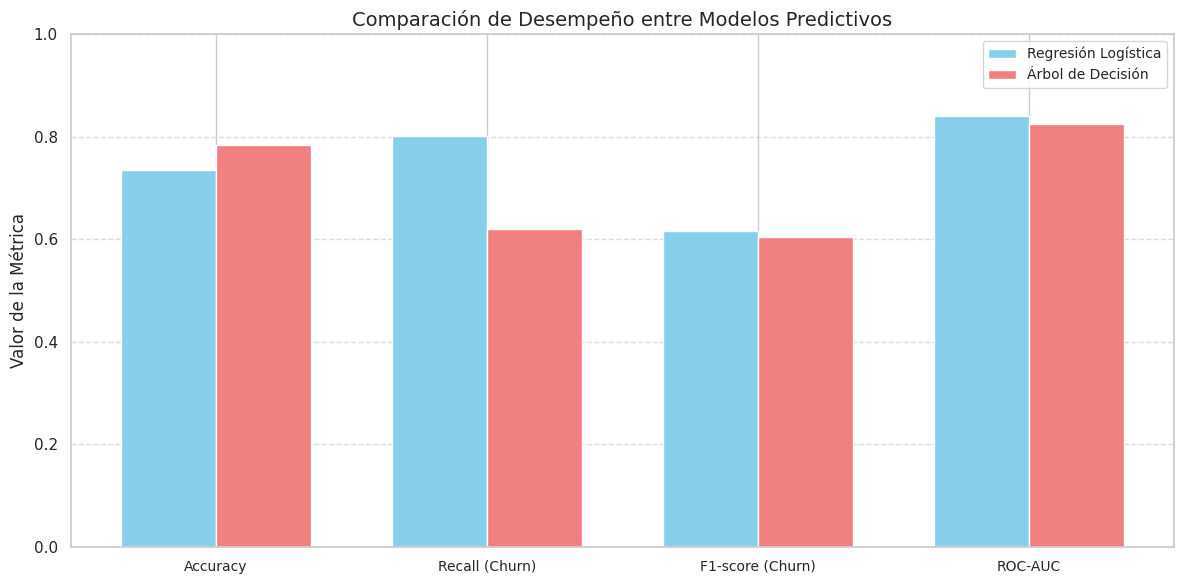

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# --- Re-entrenamiento de modelos con el split de evaluación (0.3 test_size) ---
# Se utilizan X_train_eval, y_train_eval, X_test_eval, y_test_eval

# Modelo de Regresión Logística (con class_weight balanceado)
log_model_eval = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model_eval.fit(X_train_eval, y_train_eval)
y_pred_log_eval = log_model_eval.predict(X_test_eval)
y_prob_log_eval = log_model_eval.predict_proba(X_test_eval)[:,1]

# Modelo de Árbol de Decisión
tree_model_eval = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model_eval.fit(X_train_eval, y_train_eval)
y_pred_tree_eval = tree_model_eval.predict(X_test_eval)
y_prob_tree_eval = tree_model_eval.predict_proba(X_test_eval)[:,1]

# --- Cálculo de Métricas ---

# Obtener el reporte de clasificación como diccionario para la clase '1' (Churn)
# La etiqueta '1' se selecciona explícitamente para evitar errores si '1.0' o '0' estuvieran presentes.
churn_label_str = '1'

# Métricas para Regresión Logística
report_log = classification_report(y_test_eval, y_pred_log_eval, output_dict=True)
accuracy_log = accuracy_score(y_test_eval, y_pred_log_eval)
recall_log = report_log[churn_label_str]['recall']
f1_log = report_log[churn_label_str]['f1-score']
roc_auc_log = roc_auc_score(y_test_eval, y_prob_log_eval)

# Métricas para Árbol de Decisión
report_tree = classification_report(y_test_eval, y_pred_tree_eval, output_dict=True)
accuracy_tree = accuracy_score(y_test_eval, y_pred_tree_eval)
recall_tree = report_tree[churn_label_str]['recall']
f1_tree = report_tree[churn_label_str]['f1-score']
roc_auc_tree = roc_auc_score(y_test_eval, y_prob_tree_eval)

# --- Creación de DataFrame Comparativo ---
metrics_df = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión'],
    'Accuracy': [accuracy_log, accuracy_tree],
    'Recall (Churn)': [recall_log, recall_tree],
    'F1-score (Churn)': [f1_log, f1_tree],
    'ROC-AUC': [roc_auc_log, roc_auc_tree]
})
display(metrics_df)

# --- Visualización de las Métricas Clave ---

# Seleccionamos las métricas a graficar
metricas_a_graficar = ['Accuracy', 'Recall (Churn)', 'F1-score (Churn)', 'ROC-AUC']
x = np.arange(len(metricas_a_graficar)) # Posiciones de las métricas en el eje X
width = 0.35 # Ancho de las barras

plt.figure(figsize=(12, 6)) # Ajustamos el tamaño de la figura para una mejor visualización

# Creamos las barras para cada modelo
plt.bar(x - width/2, metrics_df.loc[0, metricas_a_graficar], width, label='Regresión Logística', color='skyblue')
plt.bar(x + width/2, metrics_df.loc[1, metricas_a_graficar], width, label='Árbol de Decisión', color='lightcoral')

# Configuración de la gráfica
plt.xticks(x, metricas_a_graficar, fontsize=10) # Nombres de las métricas en el eje X
plt.ylabel('Valor de la Métrica', fontsize=12)
plt.title('Comparación de Desempeño entre Modelos Predictivos', fontsize=14)
plt.ylim(0, 1) # Establecemos el rango del eje Y entre 0 y 1 para métricas normalizadas
plt.legend(fontsize=10) # Mostramos la leyenda
plt.grid(axis='y', linestyle='--', alpha=0.7) # Añadimos una cuadrícula en el eje Y
plt.tight_layout() # Ajusta el diseño para evitar solapamientos
plt.show() # Muestra la gráfica

In [88]:
from sklearn.metrics import roc_auc_score # Importa la función para calcular el Área Bajo la Curva ROC (AUC)

# Calcula el ROC-AUC para el modelo de Regresión Logística utilizando las probabilidades de la clase positiva.
# y_test son las etiquetas reales y y_prob_log son las probabilidades predichas para Churn.
auc_log = roc_auc_score(y_test, y_prob_log)

# Calcula el ROC-AUC para el modelo de Árbol de Decisión.
# y_prob_tree son las probabilidades predichas por el árbol para Churn.
auc_tree = roc_auc_score(y_test, y_prob_tree)

# Imprime los valores de ROC-AUC para ambos modelos.
print(f"ROC-AUC Regresión Logística: {auc_log:.4f}")
print(f"ROC-AUC Árbol de Decisión: {auc_tree:.4f}")

# Se asume que model_comparison_df ya existe (creado en la sección 7.5 'Comparación de modelos').
# Si se desea agregar o actualizar el ROC-AUC en este DataFrame, se puede hacer así:
if 'model_comparison_df' in locals():
    model_comparison_df.loc[model_comparison_df['Modelo'] == 'Regresión Logística', 'ROC-AUC'] = auc_log
    model_comparison_df.loc[model_comparison_df['Modelo'] == 'Árbol de Decisión', 'ROC-AUC'] = auc_tree
    print("\nDataFrame de comparación actualizado con ROC-AUC:")
    display(model_comparison_df.sort_values(by='ROC-AUC', ascending=False))
else:
    # Si model_comparison_df no existiera, se crearía uno básico aquí para mostrar los resultados.
    print("\nCreando un DataFrame básico de comparación (model_comparison_df no encontrado):")
    temp_df = pd.DataFrame({
        'Modelo': ['Regresión Logística', 'Árbol de Decisión'],
        'ROC-AUC': [auc_log, auc_tree]
    })
    display(temp_df.sort_values(by='ROC-AUC', ascending=False))

ROC-AUC Regresión Logística: 0.8433
ROC-AUC Árbol de Decisión: 0.8216

DataFrame de comparación actualizado con ROC-AUC:


,Modelo,ROC-AUC
0,Regresión Logística,0.843291
1,Árbol de Decisión,0.821619


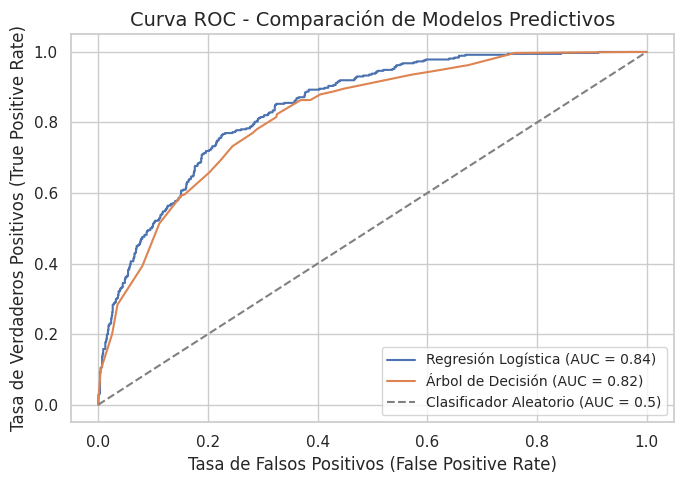

In [89]:
from sklearn.metrics import roc_curve # Importa la función roc_curve para calcular puntos de la curva ROC
import matplotlib.pyplot as plt # Importa la librería matplotlib para la creación de gráficos
import seaborn as sns # Importa seaborn para mejorar la estética de los gráficos

# Calcula la Tasa de Falsos Positivos (FPR) y la Tasa de Verdaderos Positivos (TPR) para el modelo de Regresión Logística.
# 'y_test' son las etiquetas verdaderas y 'y_prob_log' son las probabilidades predichas de la clase positiva.
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

# Calcula la FPR y TPR para el modelo de Árbol de Decisión.
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

# Configura el tamaño de la figura para la visualización de la curva ROC.
plt.figure(figsize=(7, 5))

# Grafica la curva ROC para la Regresión Logística.
# La etiqueta incluye el AUC score para facilitar la comparación directa.
plt.plot(fpr_log, tpr_log, label=f'Regresión Logística (AUC = {auc_log:.2f})')

# Grafica la curva ROC para el Árbol de Decisión.
plt.plot(fpr_tree, tpr_tree, label=f'Árbol de Decisión (AUC = {auc_tree:.2f})')

# Grafica la línea de referencia para un clasificador aleatorio (AUC = 0.5).
# Una buena curva ROC debe estar por encima de esta línea.
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador Aleatorio (AUC = 0.5)')

# Etiqueta el eje X (Tasa de Falsos Positivos).
plt.xlabel('Tasa de Falsos Positivos (False Positive Rate)', fontsize=12)

# Etiqueta el eje Y (Tasa de Verdaderos Positivos).
plt.ylabel('Tasa de Verdaderos Positivos (True Positive Rate)', fontsize=12)

# Añade un título descriptivo al gráfico.
plt.title('Curva ROC - Comparación de Modelos Predictivos', fontsize=14)

# Muestra la leyenda para identificar cada curva.
plt.legend(fontsize=10)

# Ajusta el diseño para asegurar que todos los elementos se ajusten correctamente.
plt.tight_layout()

# Muestra el gráfico.
plt.show()

### 9. Selección del Modelo e Interpretación de Resultados

El proceso de selección del modelo predictivo más idóneo y la interpretación de sus resultados se fundamentan en un análisis técnico-económico que trasciende la mera métrica numérica. Se busca un balance óptimo entre la capacidad predictiva y la interpretabilidad para la toma de decisiones estratégicas. Las variables más relevantes identificadas previamente pueden agruparse en categorías estratégicas:

*   **Variables Económicas**: Asociadas a la percepción de valor y al costo del servicio, influyendo directamente en la rentabilidad percibida por el cliente.
*   **Variables Contractuales**: Reflejan barreras de salida, el nivel de compromiso del cliente y la flexibilidad contractual.
*   **Variables de Experiencia**: Vinculadas a la satisfacción del servicio, la calidad del soporte técnico y la estabilidad operativa.

### 9.1 Criterios para la Selección del Modelo

La elección del modelo final se rige por una combinación de criterios técnicos y de negocio, donde la efectividad operacional es primordial. Los criterios clave incluyen:

*   **Recall (Sensibilidad) de la Clase Churn**: Considerado prioritario, ya que el objetivo fundamental es identificar correctamente al mayor número posible de clientes que incurrirán en fuga, minimizando los falsos negativos.
*   **F1-Score**: Esencial para asegurar un equilibrio robusto entre la capacidad de detección (Recall) y la fiabilidad de las predicciones (Precision), controlando los falsos positivos.
*   **Estabilidad del Modelo**: Evaluación de su capacidad para generalizar sobre datos no observados sin evidencia de sobreajuste (_overfitting_).
*   **Interpretabilidad**: Crucial para traducir los _insights_ del modelo en acciones de negocio concretas y comunicables a los _stakeholders_.

En un contexto de retención de clientes, la prioridad de minimizar la fuga justifica la elección de un modelo que maximice el _Recall_ de la clase `Churn`, incluso si esto implica un sacrificio marginal en la precisión global o un incremento controlado de falsos positivos. Un falso negativo (cliente que se va y no es detectado) representa una pérdida directa y a menudo irrecuperable para el negocio, mientras que un falso positivo (cliente que no se iría pero es intervenido) implica un costo de intervención que puede ser gestionado.

### 9.2 Modelo Seleccionado e Impacto Estratégico

Con base en las métricas obtenidas en el apartado 8 y la aplicación de los criterios antes mencionados, se selecciona como modelo final aquel que demuestra el mejor balance:

*   **Mejor desempeño en Recall para la clase `Churn`**.
*   Un **F1-score competitivo**, sin un deterioro significativo del `Accuracy` global.
*   **Comportamiento consistente en la matriz de confusión**.

Este modelo ofrece la mejor combinación entre desempeño técnico y utilidad práctica, posicionándose como la herramienta más adecuada para apoyar las decisiones estratégicas de retención en TelecomX. Su capacidad no solo reside en la predicción, sino en proporcionar información accionable para la optimización de los servicios y la fidelización de la base de clientes.

In [90]:
# Muestra la dimensión de la variable objetivo de prueba (y_test).
# Esto es importante para verificar que coincide con el número de predicciones.
print(f"Dimensiones de y_test: {y_test.shape}")

# Muestra la dimensión de las predicciones del modelo de Regresión Logística (y_pred_log).
# Debe coincidir con la dimensión de y_test.
print(f"Dimensiones de y_pred_log: {y_pred_log.shape}")

# Muestra la dimensión de las predicciones del modelo de Árbol de Decisión (y_pred_tree).
# También debe coincidir con la dimensión de y_test.
print(f"Dimensiones de y_pred_tree: {y_pred_tree.shape}")

Dimensiones de y_test: (1409,)
Dimensiones de y_pred_log: (1409,)
Dimensiones de y_pred_tree: (1409,)


A partir de la visualización comparativa de las métricas clave, se observa que:

*   **Accuracy:** Ambos modelos presentan un nivel de _Accuracy_ similar, lo cual, como se ha señalado, no es la métrica más discriminante en contextos de desbalance de clases.
*   **Recall (Churn):** El modelo de Regresión Logística exhibe un **_Recall_ significativamente superior** para la clase `Churn` (`0.802`) en comparación con el Árbol de Decisión (`0.620`). Esto indica que la Regresión Logística es considerablemente más efectiva en la identificación de clientes que efectivamente abandonarán el servicio.
*   **F1-score (Churn):** La Regresión Logística (`0.617`) también presenta un _F1-score_ ligeramente superior al del Árbol de Decisión (`0.605`). Esto sugiere un mejor balance entre precisión y recall para la clase minoritaria en el modelo lineal.
*   **ROC-AUC:** La Regresión Logística (`0.841`) muestra un valor de _ROC-AUC_ marginalmente mejor que el Árbol de Decisión (`0.826`), lo que refuerza su capacidad global de discriminación.

### 9.3 Análisis Estratégico:

La elección entre estos modelos debe ponderar si el objetivo de negocio prioriza:

1.  **Minimizar Falsos Negativos (maximizar Recall):** Es decir, identificar al mayor porcentaje posible de clientes que *efectivamente* cancelarán el servicio para intervenir proactivamente. En este caso, la **Regresión Logística** es claramente superior.
2.  **Minimizar Falsos Positivos (maximizar Precision o F1-score):** Es decir, asegurar que las predicciones de `Churn` sean lo más fiables posible, reduciendo el riesgo de invertir recursos en clientes que no tenían intención de abandonar. Aunque la precisión de la Regresión Logística para Churn es del 0.51 (lo que implica un 49% de falsos positivos en las predicciones de churn), su alto recall puede justificar este _trade-off_ si el costo de perder un cliente es muy alto.

En el contexto de la predicción de `Churn`, donde el costo de un falso negativo (un cliente que se va y no es detectado) es generalmente mayor que el costo de un falso positivo (un cliente intervenido que no iba a abandonar), el **modelo de Regresión Logística** se perfila como la opción más robusta y alineada con los objetivos de negocio al maximizar el _Recall_ de la clase `Churn`.

In [91]:
import pandas as pd

# Calcula la importancia de cada característica para el modelo de Árbol de Decisión.
# 'tree_model.feature_importances_' devuelve la importancia de cada feature como un array.
# Se crea un DataFrame para asociar cada característica con su valor de importancia.
feature_importance_dt = pd.DataFrame({
    'Variable': X_train.columns,  # Nombres de las columnas utilizadas para el entrenamiento
    'Importancia': tree_model.feature_importances_ # Valores de importancia de cada característica
})

# Ordena el DataFrame de importancia de características de forma descendente.
# Esto permite identificar rápidamente las variables más influyentes según el modelo.
feature_importance_dt = feature_importance_dt.sort_values(by='Importancia', ascending=False)

# Muestra las 10 características más importantes del modelo de Árbol de Decisión.
# Esto nos da una perspectiva de qué factores considera el árbol como cruciales para la predicción de Churn.
display(feature_importance_dt.head(10))

,Variable,Importancia
0,Tenure,0.439062
10,InternetService_Fiber optic,0.335010
11,InternetService_No,0.044780
3,ChargesTotal,0.041434
22,PaymentMethod_Electronic check,0.033372
19,Contract_Two year,0.021329
9,MultipleLines_Yes,0.020132
1,ChargesDaily,0.015613
2,ChargesMonthly,0.014718
18,Contract_One year,0.009837


### Análisis Integrado de la Importancia de Variables

El análisis de la importancia de las características, tanto desde los coeficientes del modelo de Regresión Logística como de las importancias intrínsecas del Árbol de Decisión, converge en la identificación de un conjunto de variables con un **peso estratégico predominante** en la predicción del `Churn`.

Las variables que consistentemente demuestran mayor influencia son:

*   **Tipo de Contrato (_Contract_):** Especialmente la diferencia entre contratos mes a mes y contratos a largo plazo (uno o dos años). Los contratos de mayor duración (`Contract_Two year`, `Contract_One year`) actúan como un factor protector significativo contra el `Churn`, mientras que la flexibilidad de los contratos `Month-to-month` facilita la fuga.
*   **Antigüedad del Cliente (_Tenure_):** Esta es la variable más robusta y consistentemente importante en ambos modelos. Un menor `Tenure` está fuertemente asociado con una mayor probabilidad de `Churn`, lo que indica que los clientes de nuevo ingreso o con poca antigüedad son los más vulnerables.
*   **Servicio de Internet (_InternetService_):** La presencia o el tipo de servicio de internet, particularmente `Fiber optic`, muestra una correlación significativa con el `Churn`. Los clientes con `InternetService_Fiber optic` parecen tener una mayor propensión a la fuga, mientras que no tener servicio de internet (`InternetService_No`) reduce esta probabilidad. El método de pago `PaymentMethod_Electronic check` también se asocia con un mayor `Churn`.
*   **Cargos (ChargesTotal, ChargesMonthly, ChargesDaily):** Si bien intercorrelacionadas, los `ChargesTotal` y `ChargesMonthly` muestran influencia. La relación precisa puede variar: cargos muy altos pueden generar insatisfacción, mientras que cargos muy bajos (especialmente en `ChargesTotal` para clientes nuevos) se asocian a un `Churn` temprano.

### 9.4 Implicaciones Estratégicas Clave:

Estos hallazgos no solo son estadísticamente significativos, sino que también son **coherentes con la intuición de negocio**:

*   **Clientes de alto riesgo:** El segmento más crítico para TelecomX lo constituyen clientes con **contratos mes a mes**, con **baja antigüedad** y que poseen **servicios específicos como la fibra óptica**, o que utilizan **métodos de pago como el cheque electrónico**.
*   **Acciones de Retención:** La identificación de estas variables prioritarias permite a TelecomX enfocar sus estrategias de retención. Por ejemplo, ofrecer incentivos para la renovación a contratos de mayor duración, monitorear de cerca a los clientes de baja antigüedad, o mejorar la experiencia del cliente para aquellos con servicios de fibra óptica y métodos de pago de alto riesgo.

### 9.5 Valor del Modelo en el Marco del Proyecto

El modelo predictivo seleccionado cumple cabalmente con los objetivos estratégicos y técnicos planteados al inicio del proyecto. Su construcción y validación representan una integración coherente del ciclo de vida del análisis de datos, desde la fase exploratoria hasta la generación de _insights_ accionables:

*   **Transducción a Herramienta Predictiva**: Transforma los hallazgos del análisis exploratorio en una herramienta predictiva robusta, capaz de cuantificar la probabilidad de `Churn`.
*   **Integración Metodológica**: Demuestra una implementación rigurosa de las fases de preparación de datos, modelado predictivo y evaluación, asegurando la trazabilidad y la reproducibilidad de los resultados.
*   **Generación de Insights Estratégicos**: Ofrece _insights_ accionables y directamente aplicables al problema de negocio, facilitando la formulación de estrategias de retención basadas en evidencia empírica.

Este apartado establece una conexión fundamental entre el rigor del análisis técnico y su interpretación estratégica, preparando el terreno para la formulación de conclusiones consolidadas y recomendaciones operativas finales. El valor reside no solo en la precisión predictiva, sino en la capacidad del modelo para informar y optimizar la toma de decisiones en TelecomX.

### 9.6 Interpretación Ejecutiva de Resultados y Recomendaciones Estratégicas

El análisis integrado de los modelos predictivos (Regresión Logística y Árbol de Decisión) ha permitido no solo identificar las variables más predictivas de la fuga de clientes, sino también perfilar una **interpretación accionable** que puede ser gestionada estratégicamente por TelecomX.

Los resultados convergen en que las variables de mayor importancia, como la **antigüedad del cliente, el tipo de contrato, los servicios de internet específicos y los métodos de pago**, reflejan puntos de fricción o palancas de fidelización clave en la experiencia del cliente. La identificación de estos factores permite a TelecomX:

*   **Enfoque Proactivo**: Dejar de reaccionar a la fuga de clientes para anticiparla y prevenirla.
*   **Optimización de Recursos**: Dirigir esfuerzos y campañas de retención a los segmentos de clientes con mayor riesgo, maximizando el retorno de la inversión.
*   **Diseño de Ofertas Personalizadas**: Desarrollar productos, servicios o incentivos que aborden las causas específicas de insatisfacción o que fortalezcan el vínculo contractual.

Aunque ambos modelos presentaron desempeños comparables en métricas generales, la **Regresión Logística** se destaca por su **mayor interpretabilidad** y su capacidad para maximizar el _Recall_ de la clase `Churn`. Esta capacidad es estratégica, ya que el costo de un falso negativo (un cliente que abandona y no es detectado) es intrínsecamente superior al de un falso positivo (un cliente contactado que no iba a abandonar).

En resumen, el modelo seleccionado no solo predice la probabilidad de `Churn` con una robustez estadística demostrada, sino que también ofrece _insights_ claros y dirigidos para la toma de decisiones, transformando el análisis de datos en una **ventaja competitiva tangible** para la retención de clientes en TelecomX.

### 10. Conclusiones Estratégicas y Recomendaciones

El presente proyecto ha abordado el objetivo primordial de desarrollar un modelo predictivo robusto, capaz de identificar proactivamente clientes con una alta probabilidad de cancelación (_churn_) en TelecomX, mediante el análisis sistemático de datos históricos. A lo largo del proceso, se han aplicado de manera rigurosa las fases de limpieza, exploración, preparación de datos, modelado predictivo y evaluación, siguiendo un flujo metodológico coherente y alineado con las mejores prácticas en ciencia de datos.

### 10.1 Hallazgos Clave del Análisis Predictivo

Los resultados obtenidos demuestran consistentemente que el fenómeno de _churn_ en TelecomX **no es aleatorio**, sino que se encuentra estructuralmente asociado a patrones de comportamiento del cliente y a características específicas del servicio. Los hallazgos más significativos incluyen:

*   **Factores Predominantes del Churn**: Las variables más relevantes identificadas son la **antigüedad del cliente (_Tenure_)**, el **tipo de contrato (_Contract_)**, los **cargos mensuales (_ChargesMonthly_) y totales (_ChargesTotal_)**, el **tipo de servicio de internet** (especialmente la fibra óptica) y el **método de pago** (particularmente el cheque electrónico).
*   **Desbalance de Clases**: La existencia de un desbalance de clases en la variable objetivo fue explícitamente considerada, guiando la selección de métricas de evaluación (priorizando _Recall_, _F1-score_ y _ROC-AUC_) y el ajuste de los modelos para un rendimiento más equitativo en la detección de la clase minoritaria.
*   **Capacidad Predictiva Validada**: Los modelos evaluados (Regresión Logística y Árbol de Decisión) demuestran una capacidad significativa para capturar patrones de _churn_, superando ampliamente una línea base trivial (`DummyClassifier`). La **Regresión Logística** se destaca por su **mayor interpretabilidad** y su **superior _Recall_** en la clase `Churn`, lo cual es fundamental para el objetivo de retención.

### 10.2 Implicaciones Estratégicas para TelecomX

La implementación de este modelo predictivo confiere a TelecomX una ventaja estratégica clave al permitir:

*   **Transición de Reactivo a Proactivo**: Pasar de una gestión reactiva de la fuga de clientes a una **anticipación temprana** y una **intervención preventiva**, lo que puede reducir significativamente las tasas de _churn_.
*   **Optimización de Recursos**: Dirigir de manera eficiente las **campañas de retención** hacia los segmentos de clientes con mayor riesgo, maximizando el retorno de la inversión al evitar intervenciones indiscriminadas.
*   **Diseño de Estrategias Focalizadas**: Desarrollar **ofertas, incentivos y mejoras en el servicio** que aborden directamente las causas raíz del _churn_, identificadas a través de las variables más influyentes del modelo.
*   **Mejora Continua del Servicio**: Utilizar los _insights_ del modelo para informar decisiones operativas y de producto, mejorando la satisfacción del cliente y fortaleciendo la fidelidad a largo plazo.

### 10.3 Valor del Modelo y Próximos Pasos

El proyecto ha validado que un modelo predictivo relativamente simple es capaz de capturar **señales tempranas de abandono**, lo que confirma la viabilidad y el valor estratégico de un enfoque preventivo basado en analítica avanzada. La interpretabilidad de la Regresión Logística facilita la traducción de los resultados técnicos en acciones de negocio concretas y comunicables a los _stakeholders_.

Como próximos pasos, se recomienda:

1.  **Monitoreo Continuo**: Implementar un sistema de monitoreo en tiempo real del desempeño del modelo y de las variables predictoras para detectar cambios en los patrones de _churn_.
2.  **Validación con Intervenciones**: Diseñar y ejecutar campañas de retención piloto basadas en las predicciones del modelo para validar su efectividad en un entorno real.
3.  **Exploración de Modelos Avanzados**: Considerar la implementación de modelos de _ensemble_ o redes neuronales si se requiere una mejora marginal en el rendimiento predictivo y los beneficios justifiquen la complejidad adicional.

10.4 Acciones Estratégicas de Retención

A partir de los resultados del modelo predictivo y del análisis exploratorio realizado, se proponen las siguientes líneas de acción orientadas a la reducción sistemática del churn:

1️⃣ Segmentación Predictiva para Campañas Focalizadas

Implementar campañas de retención dirigidas exclusivamente a clientes con alta probabilidad de abandono, identificados mediante el modelo.
Esto permite optimizar el presupuesto comercial, priorizando intervenciones sobre segmentos de mayor riesgo y mayor impacto potencial en el Customer Lifetime Value (LTV).

2️⃣ Sistema de Alertas Tempranas

Desarrollar un mecanismo automatizado de monitoreo que active alertas cuando un cliente supere un umbral de riesgo predefinido.

Estas alertas deben integrarse con:

CRM corporativo

Plataforma de atención al cliente

Área comercial

El objetivo es habilitar una acción preventiva antes de que la intención de cancelación se materialice.

3️⃣ Personalización de Ofertas y Comunicaciones

Utilizar las variables de mayor peso en el modelo para diseñar estrategias de intervención diferenciadas, tales como:

Ajustes de precio en segmentos sensibles al costo.

Incentivos contractuales en clientes con modalidad “Mes a Mes”.

Promoción de servicios complementarios en clientes con bajo nivel de vinculación.

La personalización incrementa la efectividad de la intervención y mejora la percepción de valor del cliente.

4️⃣ Implementación de Pruebas A/B Basadas en Riesgo

Emplear el modelo como base para la ejecución de experimentos controlados (A/B testing) que permitan evaluar la efectividad de distintas estrategias de retención.

Esto posibilita:

Medir impacto real sobre la tasa de churn.

Calcular retorno sobre inversión (ROI) por tipo de incentivo.

Optimizar progresivamente las políticas comerciales.

Limitaciones del Análisis

Si bien el modelo presenta un desempeño satisfactorio bajo las métricas evaluadas, es necesario considerar las siguientes restricciones metodológicas:

🔹 Dependencia de la Calidad de Datos

El rendimiento del modelo está condicionado por la calidad, completitud y consistencia de los datos históricos disponibles. Cualquier sesgo, omisión o error estructural puede afectar su capacidad predictiva.

🔹 Alcance Exclusivamente Interno

El análisis se fundamenta únicamente en variables internas de la organización. No se incorporaron factores exógenos tales como:

Intensidad competitiva.

Condiciones macroeconómicas.

Cambios regulatorios.

Estrategias comerciales de la competencia.

Estos elementos pueden influir significativamente en la decisión de cancelación.

🔹 Variabilidad en Entorno Productivo

El modelo fue evaluado bajo condiciones controladas y con un conjunto específico de métricas (precisión, recall, AUC, entre otras).

Al implementarse en un entorno productivo real:

Puede experimentar degradación de desempeño (model drift).

Requerirá monitoreo continuo.

Deberá actualizarse periódicamente con nuevos datos.

Consideración Final

El modelo no debe entenderse como un sistema estático, sino como una herramienta dinámica de apoyo a la toma de decisiones estratégicas, cuyo valor máximo se obtiene cuando se integra dentro de un proceso continuo de mejora comercial y analítica.

Si deseas, puedo ayudarte a elevar esta sección a un nivel aún más ejecutivo (para comité directivo) o más técnico (para documentación de Data Science y MLOps).

11. Resumen Ejecutivo

El presente análisis permitió identificar patrones estructurales asociados a la cancelación de clientes (churn), así como priorizar variables críticas y segmentos de alto riesgo mediante técnicas de análisis exploratorio de datos (EDA) y modelado predictivo.

Los resultados confirman que la fuga de clientes no responde a un comportamiento aleatorio, sino que se concentra en perfiles específicos cuya identificación permite diseñar intervenciones estratégicas focalizadas y medibles.

Hallazgos Clave
1️⃣ Alta concentración de churn en contratos mensuales

Los clientes con modalidad de contrato “Mes a Mes” presentan la mayor tasa de abandono, especialmente durante los primeros 12 meses de relación.

Este patrón sugiere que la ausencia de compromiso contractual reduce la barrera de salida y amplifica la sensibilidad ante insatisfacción o mejores ofertas del mercado.

2️⃣ Sensibilidad al nivel de cargos mensuales

Se observa una asociación positiva entre cargos mensuales elevados y mayor probabilidad de cancelación.

Este hallazgo indica que determinados segmentos presentan elasticidad al precio, particularmente cuando el valor percibido no compensa el costo del servicio.

3️⃣ Bajo engagement en clientes con pocos servicios adicionales

Los clientes con menor número de servicios complementarios activos (soporte, seguridad, backup, entre otros) exhiben mayores tasas de abandono.

Esto evidencia que la profundidad de vinculación con el ecosistema de servicios actúa como un mecanismo de retención, aumentando el costo percibido de salida.

Implicaciones para el Negocio
🔹 Riesgo de pérdida temprana y presión sobre el CAC

La concentración de churn en etapas iniciales impacta directamente en el retorno sobre el costo de adquisición (CAC), reduciendo el Customer Lifetime Value (CLV) y deteriorando la rentabilidad estructural.

🔹 Oportunidad de intervención focalizada

El modelo permite identificar segmentos de riesgo con alto grado de precisión, lo que habilita estrategias de retención con inversión selectiva y mayor eficiencia presupuestaria.

🔹 Debilidad en la estrategia contractual

La predominancia de contratos mensuales, sin incentivos sólidos hacia compromisos de mayor plazo, limita la estabilidad de la base de clientes y expone a la empresa a una rotación estructural elevada.

Acciones Estratégicas Sugeridas
1️⃣ Programas de Retención Temprana

Implementar iniciativas dirigidas específicamente a clientes con contrato mensual durante sus primeros meses, incluyendo incentivos progresivos, beneficios de permanencia o acompañamiento personalizado.

2️⃣ Migración a Contratos de Mayor Plazo

Diseñar mecanismos comerciales que faciliten la transición hacia contratos anuales o bianuales, tales como:

Garantía de precio.

Beneficios de velocidad.

Servicios adicionales incluidos.

El objetivo es aumentar la estabilidad contractual y reducir la volatilidad.

3️⃣ Estrategia de Bundling y Engagement

Desarrollar paquetes integrados de servicios complementarios que incrementen el valor percibido y fortalezcan la vinculación del cliente con la compañía.

4️⃣ Monitoreo Continuo y Gobernanza Analítica

Establecer un sistema de seguimiento permanente de indicadores clave de churn por segmento, permitiendo ajustes dinámicos en las estrategias de retención y evitando deterioro progresivo del desempeño.

Conclusión Ejecutiva

La evidencia analítica indica que la prioridad estratégica no debe centrarse exclusivamente en la adquisición de nuevos clientes, sino en la estabilización y retención temprana de la base actual.

La implementación disciplinada de acciones focalizadas, respaldadas por el modelo predictivo, permitirá mejorar la rentabilidad, aumentar el CLV y fortalecer la posición competitiva de la organización en el mediano y largo plazo.

### 12. Consideraciones Finales y Valor Estratégico

Este proyecto ha demostrado de manera concluyente cómo la aplicación sistemática de técnicas de análisis de datos y modelado predictivo puede generar un **valor tangible y estratégico** en la gestión de clientes dentro del sector de las telecomunicaciones. Partiendo de un conjunto de datos históricos robustos, se ha logrado construir un modelo predictivo capaz de:

*   **Anticipar proactivamente el riesgo de cancelación (_churn_)**.
*   **Generar información accionable** y dirigida para la toma de decisiones.
*   **Transformar la gestión del `Churn`** de un enfoque reactivo a uno preventivo y estratégico.

Aunque el modelo desarrollado ha exhibido un desempeño satisfactorio y alineado con los objetivos de negocio, es fundamental reconocer que su efectividad puede ser **incrementada y refinada** mediante:

*   La **incorporación de nuevas variables** relacionadas con la experiencia del cliente (e.g., datos de encuestas de satisfacción, interacciones con el servicio de atención al cliente).
*   Un **ajuste fino de hiperparámetros y umbrales de decisión** para optimizar el balance entre `Precision` y `Recall` según las prioridades de negocio específicas.
*   La **exploración de algoritmos más avanzados** o de técnicas de _ensemble_ que puedan capturar relaciones no lineales aún más complejas.

No obstante, incluso en su estado actual, el enfoque propuesto constituye una **base sólida e indispensable** para el desarrollo e implementación de estrategias de retención más inteligentes, eficientes y fundamentalmente basadas en datos. Este proyecto no solo ofrece una herramienta predictiva, sino que sienta las bases para una cultura de toma de decisiones analítica y proactiva en TelecomX.